# Proyecto de clustering de segmentación de países por datos socio-económicos

[Curso de Clustering con Python y scikit-learn](https://platzi.com/cursos/clustering)

## Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns

## Carga de datos

In [2]:
df_country = pd.read_csv('../data/raw/Country-data.csv')

In [3]:
df_country.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Manejando valores nulos

In [4]:
df_country.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## Validando duplicados

In [5]:
df_country[df_country.duplicated()]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp


## Análisis de distribución

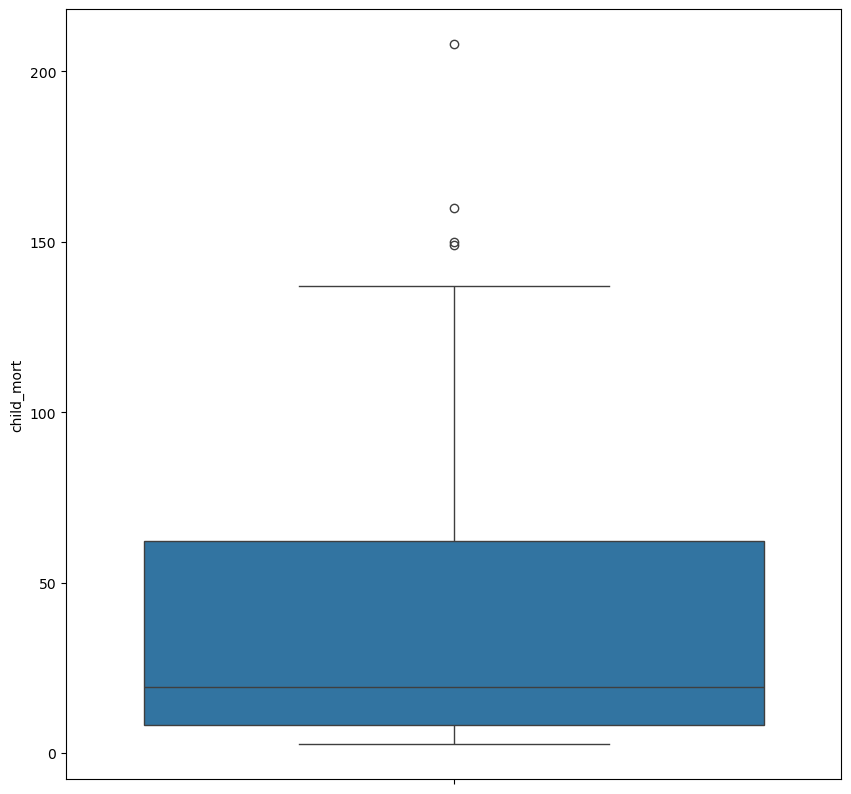

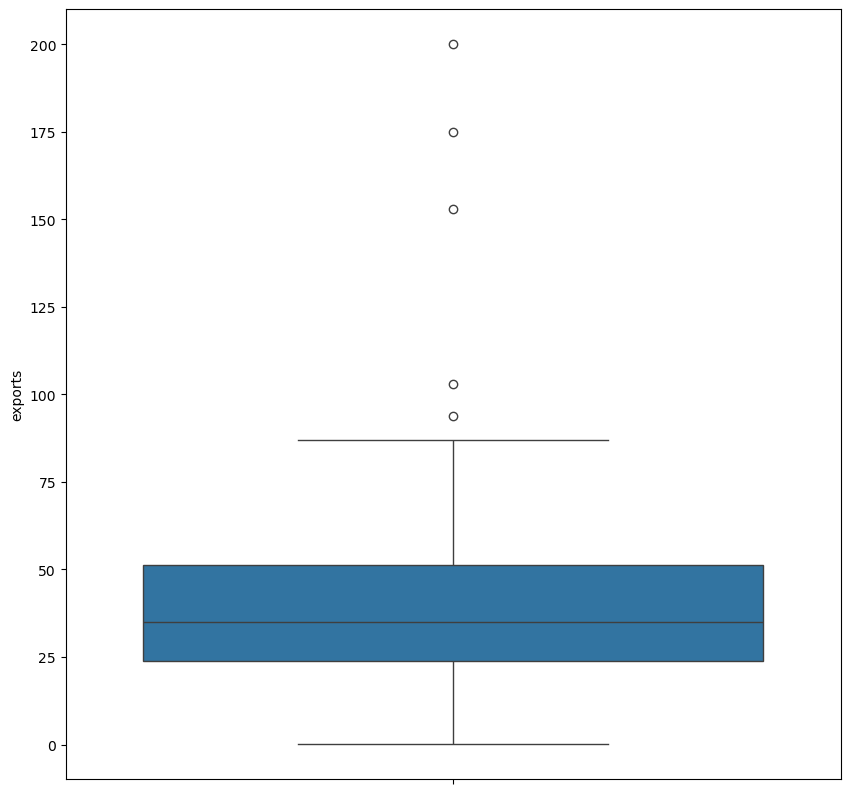

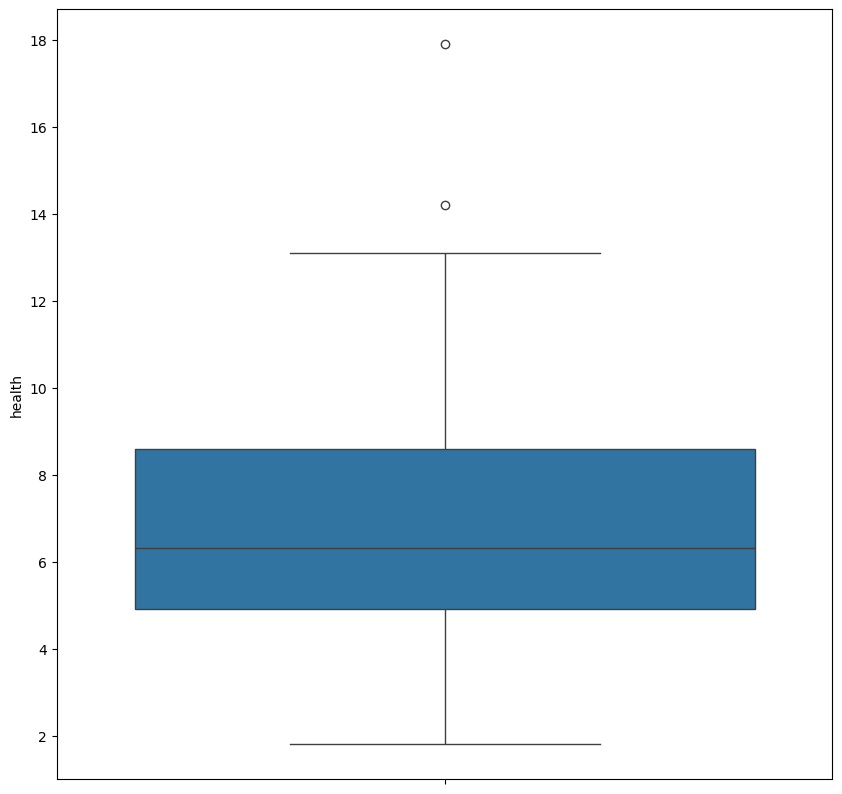

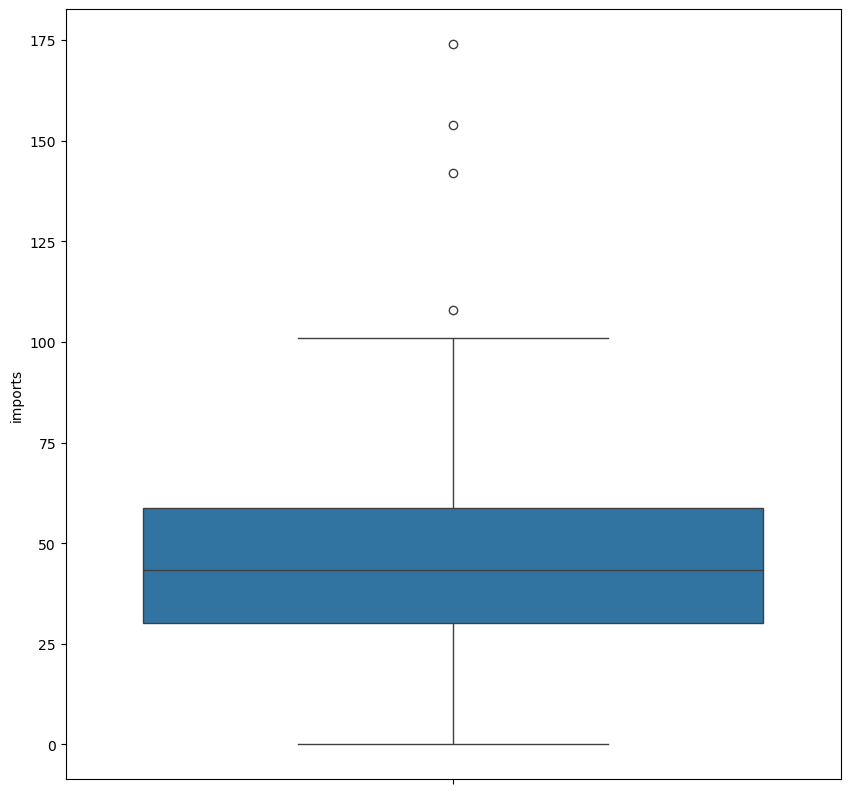

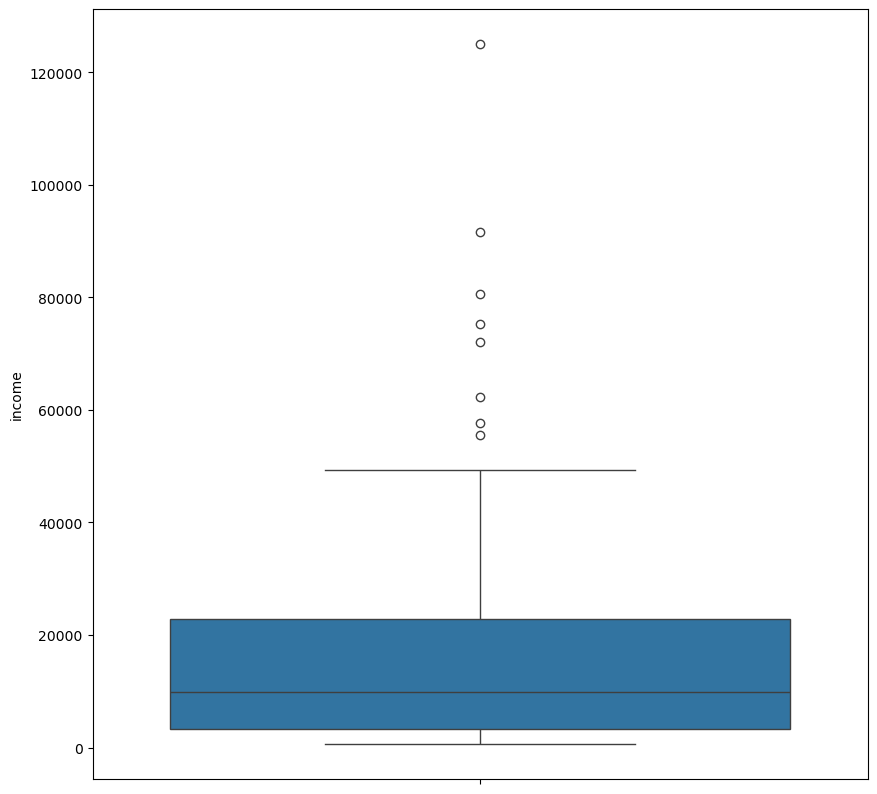

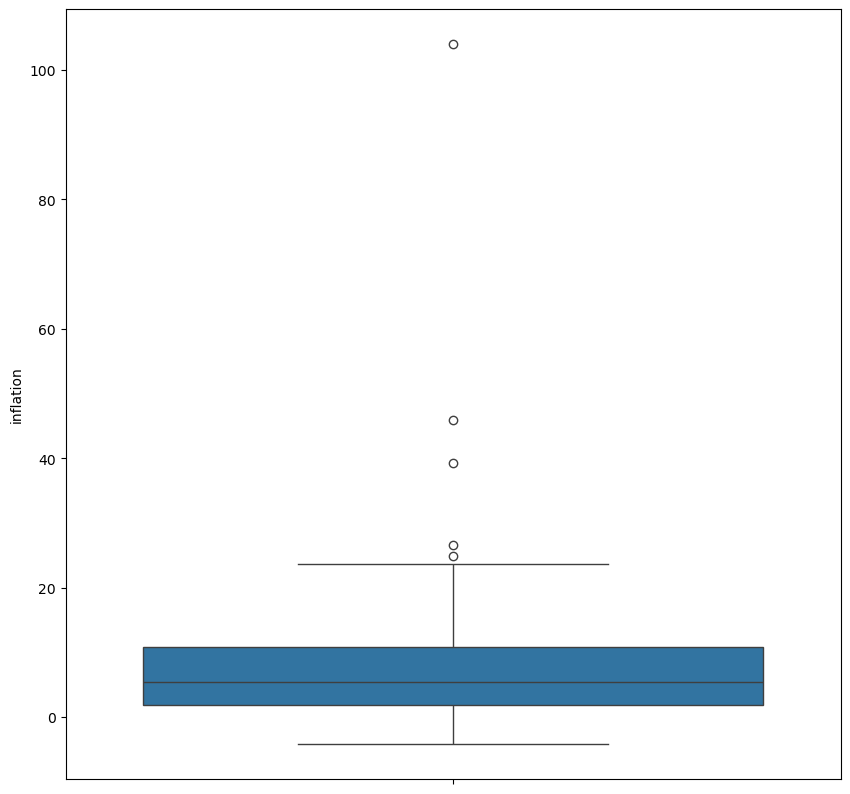

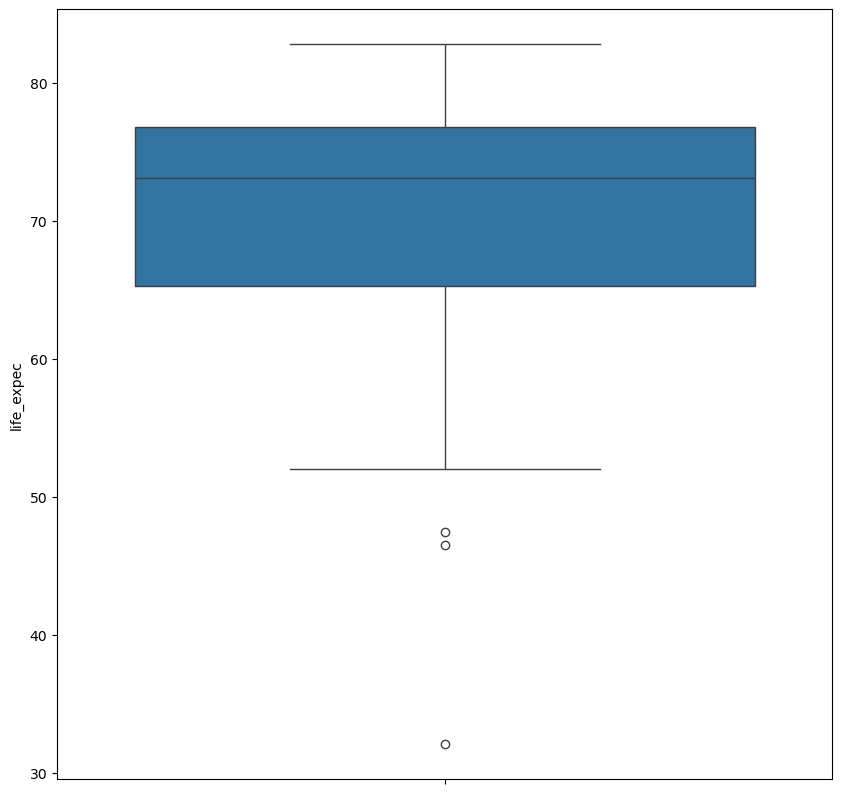

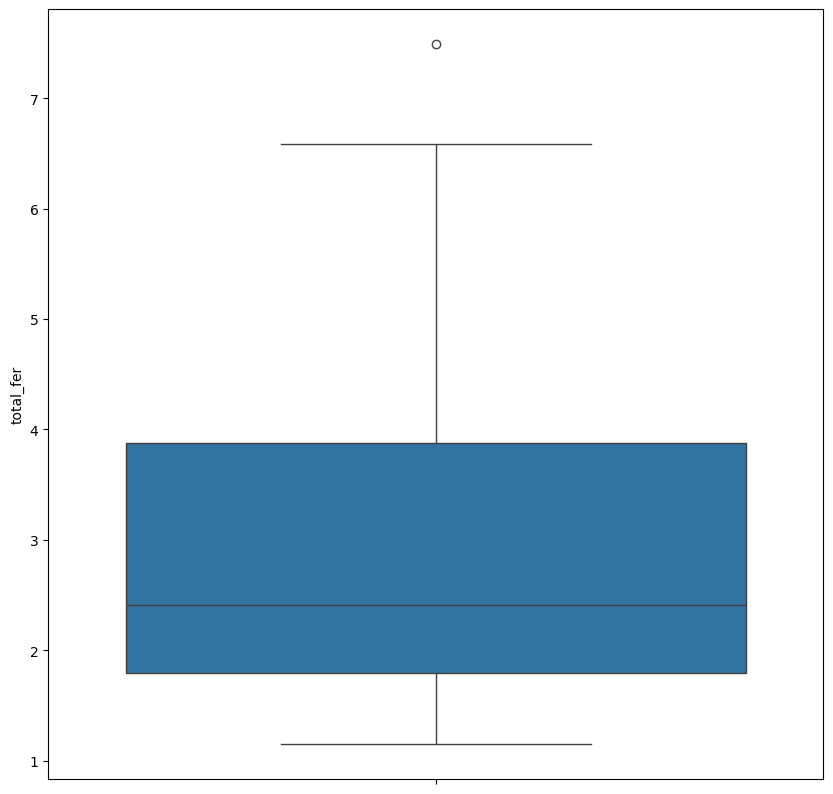

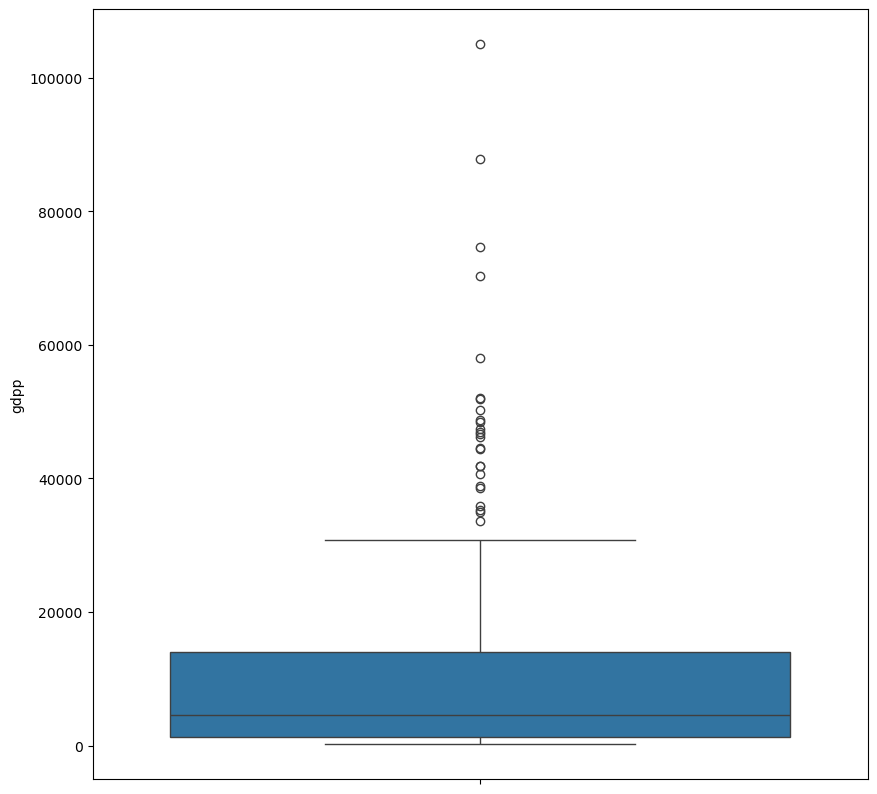

In [6]:

# Selecciona las columnas que no son de tipo objeto (es decir, columnas numéricas)


int_cols = df_country.select_dtypes(exclude='object').columns 
for _ in int_cols:
    plt.figure(figsize=(10,10))
    sns.boxplot(data=df_country, y= _)
    plt.show()

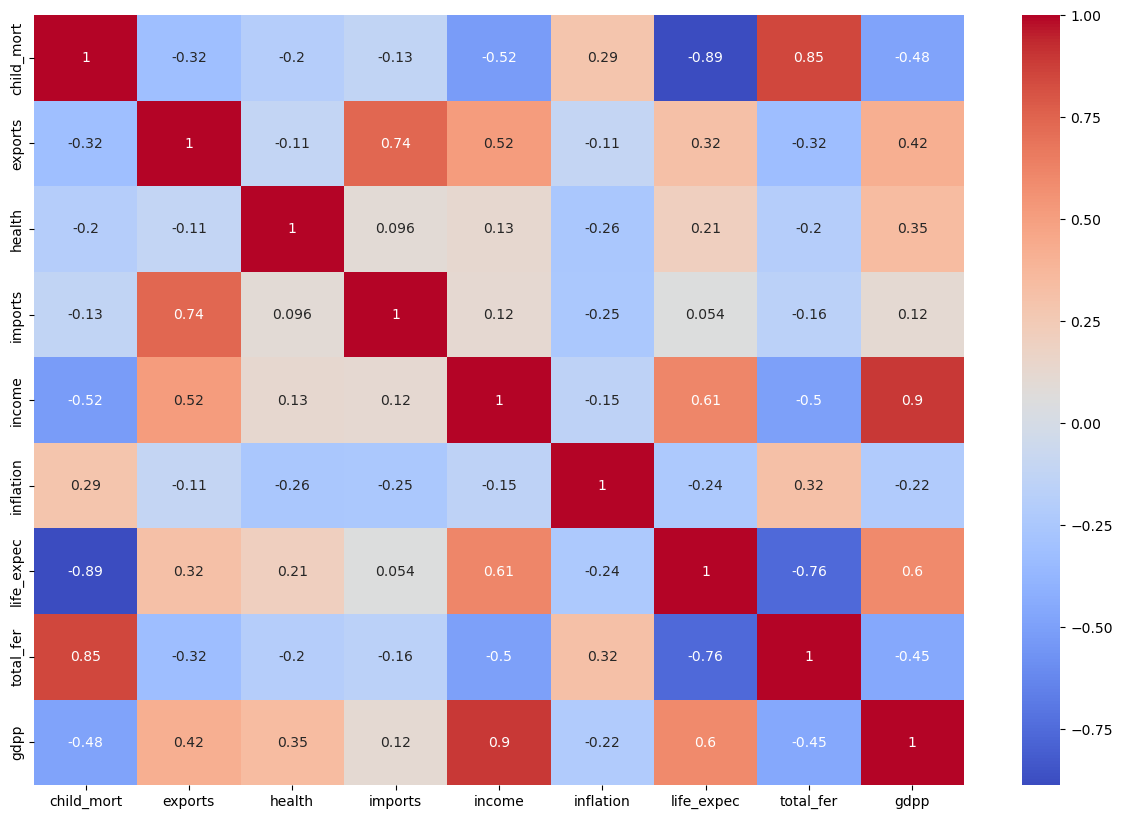

In [7]:
fig = plt.figure(figsize=(15,10))
sns.heatmap(df_country.drop('country', axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

## Escalar datos

In [8]:
from sklearn.preprocessing import StandardScaler
scaaler = StandardScaler()
df_country_scaled = scaaler.fit_transform(df_country.drop('country',axis=1))

In [9]:
df_country_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]], shape=(167, 9))

In [10]:
df_country_scaled = pd.DataFrame(df_country_scaled, columns = df_country.drop('country',axis=1).columns )

In [11]:
df_country_scaled

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
...,...,...,...,...,...,...,...,...,...
162,-0.225578,0.200917,-0.571711,0.240700,-0.738527,-0.489784,-0.852161,0.365754,-0.546913
163,-0.526514,-0.461363,-0.695862,-1.213499,-0.033542,3.616865,0.546361,-0.316678,0.029323
164,-0.372315,1.130305,0.008877,1.380030,-0.658404,0.409732,0.286958,-0.661206,-0.637754
165,0.448417,-0.406478,-0.597272,-0.517472,-0.658924,1.500916,-0.344633,1.140944,-0.637754


## PCA

In [12]:
from sklearn.decomposition import PCA 

In [13]:
pca = PCA()
pca.fit(df_country_scaled)
pca_data_scaled = pca.transform(df_country_scaled)
pca_data_scaled

array([[-2.91302459,  0.09562058, -0.7181185 , ..., -0.38300026,
        -0.41507602,  0.01414844],
       [ 0.42991133, -0.58815567, -0.3334855 , ..., -0.24891887,
         0.22104247, -0.17331578],
       [-0.28522508, -0.45517441,  1.22150481, ...,  0.08721359,
         0.18416209, -0.08403718],
       ...,
       [ 0.49852439,  1.39074432, -0.23852611, ...,  0.14362677,
         0.21759009,  0.03652231],
       [-1.88745106, -0.10945301,  1.10975159, ..., -0.06025631,
        -0.08949452,  0.09604924],
       [-2.86406392,  0.48599799,  0.22316658, ...,  0.44218462,
        -0.66433809,  0.44148176]], shape=(167, 9))

In [14]:
var = pca.explained_variance_ratio_
print(var)

[0.4595174  0.17181626 0.13004259 0.11053162 0.07340211 0.02484235
 0.0126043  0.00981282 0.00743056]


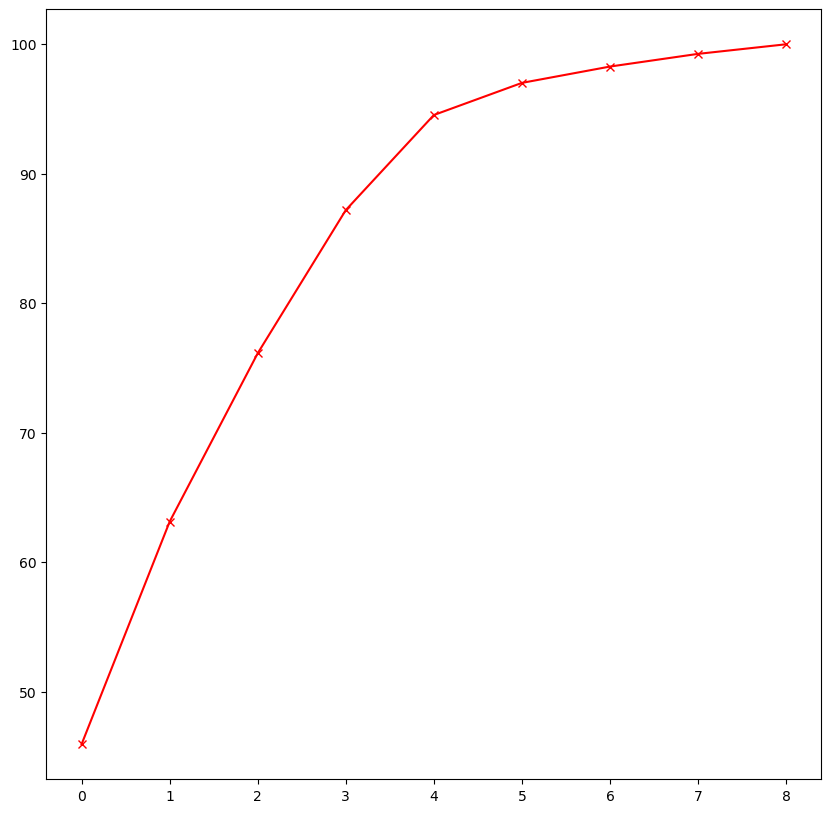

In [15]:
cum_var = np.cumsum(np.round(var, decimals=4)*100) 
plt.figure(figsize=(10,10))
plt.plot(cum_var, 'r-x')
plt.show()

In [16]:
pca_data_standard = pd.DataFrame(pca_data_scaled)
pca_data_standard.drop([4,5,6,7,8],axis=1, inplace=True)

In [17]:
pca_data_standard

,0,1,2,3
0,-2.913025,0.095621,-0.718118,1.005255
1,0.429911,-0.588156,-0.333486,-1.161059
2,-0.285225,-0.455174,1.221505,-0.868115
3,-2.932423,1.695555,1.525044,0.839625
4,1.033576,0.136659,-0.225721,-0.847063
...,...,...,...,...
162,-0.820631,0.639570,-0.389923,-0.706595
163,-0.551036,-1.233886,3.101350,-0.115311
164,0.498524,1.390744,-0.238526,-1.074098
165,-1.887451,-0.109453,1.109752,0.056257


## Importar librerías para clustering

In [18]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## K-means

### PCA

In [19]:
Sum_of_squared_distances = []
silhouette_scores = []
K = range(2,15) 
for _ in K:
    km = KMeans(n_clusters = _)
    y = km.fit_predict(pca_data_standard)
    Sum_of_squared_distances.append(km.inertia_)
    silhouette_scores.append(silhouette_score(pca_data_standard,y))

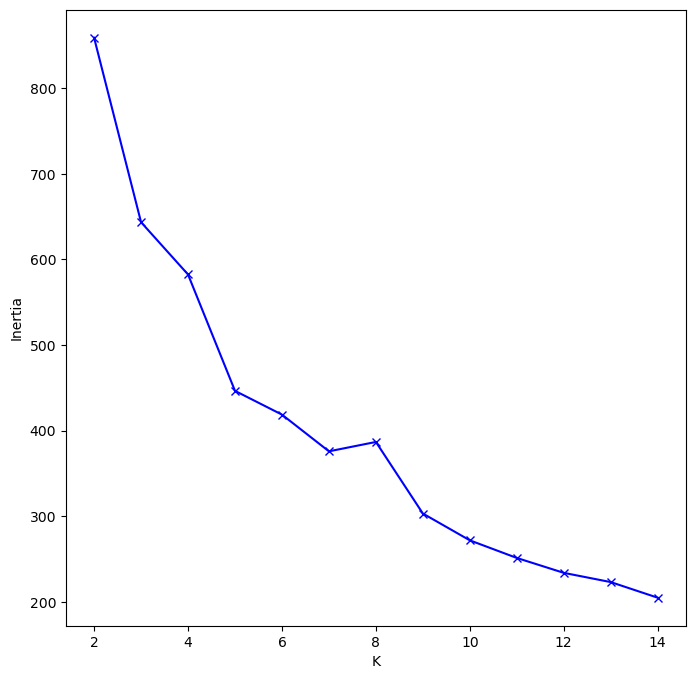

In [20]:
fig = plt.figure(figsize=(8,8))
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

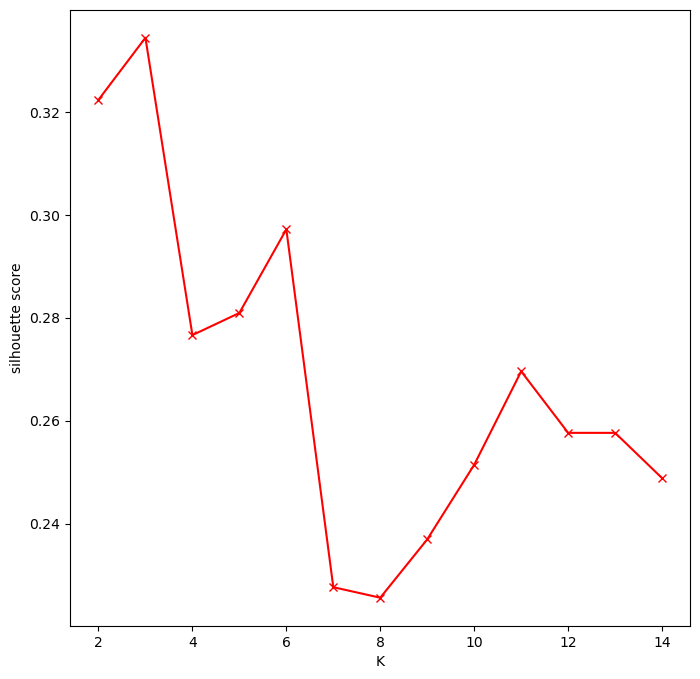

In [21]:
fig = plt.figure(figsize=(8,8))
plt.plot(K, silhouette_scores, 'rx-')
plt.xlabel('K')
plt.ylabel('silhouette score')
plt.show()

In [22]:
km = KMeans(n_clusters = 4)
y = km.fit_predict(pca_data_standard)
print(silhouette_score(pca_data_standard, y))
df_country['k_means_pca'] = y

0.3555412905042445


### Sin PCA

In [23]:
Sum_of_squared_distances = []
silhouette_scores = []
K = range(2,15) 
for _ in K:
    km = KMeans(n_clusters = _)
    y = km.fit_predict(df_country_scaled)
    Sum_of_squared_distances.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df_country_scaled,y))

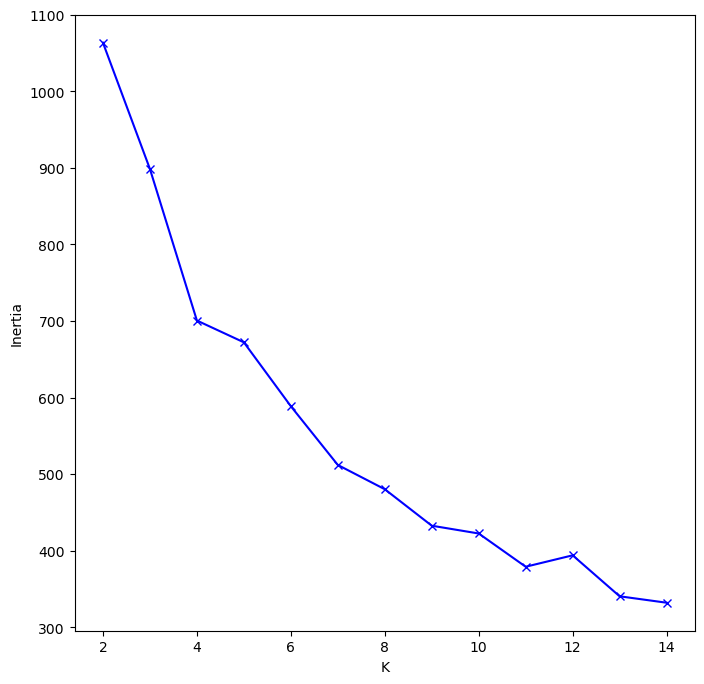

In [24]:
fig = plt.figure(figsize=(8,8))
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

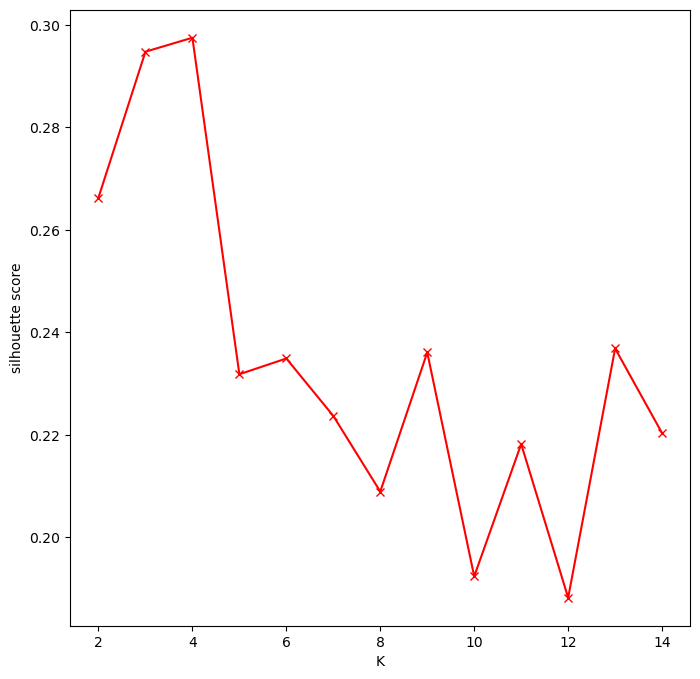

In [25]:
fig = plt.figure(figsize=(8,8))
plt.plot(K, silhouette_scores, 'rx-')
plt.xlabel('K')
plt.ylabel('silhouette score')
plt.show()

In [26]:
km = KMeans(n_clusters = 5)
y = km.fit_predict(df_country_scaled)
print(silhouette_score(df_country_scaled, y))
df_country['k_means'] = y

0.3065522876043576


## Agglomerativen hierarchical clustering

### PCA

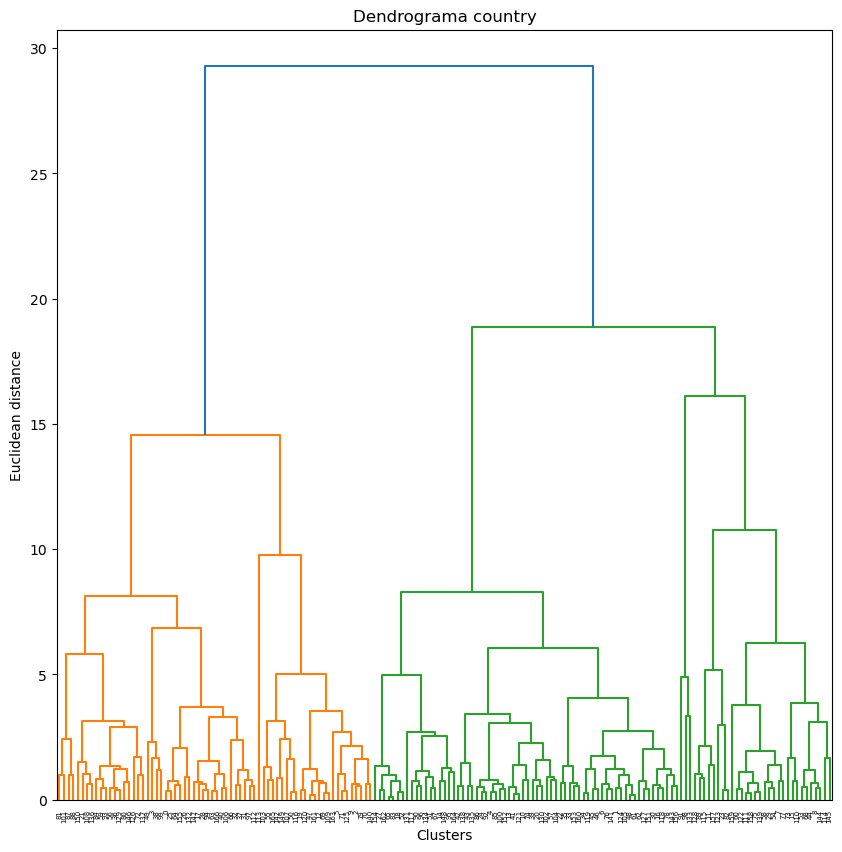

In [27]:
fig = plt.figure(figsize=(10,10))
dendrogram_plot = dendrogram(linkage(pca_data_standard, method='ward'))
plt.title('Dendrograma country')
plt.xlabel('Clusters')
plt.ylabel('Euclidean distance')
plt.show()

In [28]:
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
y_hc = hc.fit_predict(pca_data_standard)
print(silhouette_score(pca_data_standard,y_hc ))
df_country['hc_pca'] = y_hc

0.3070110704080524


### Sin PCA

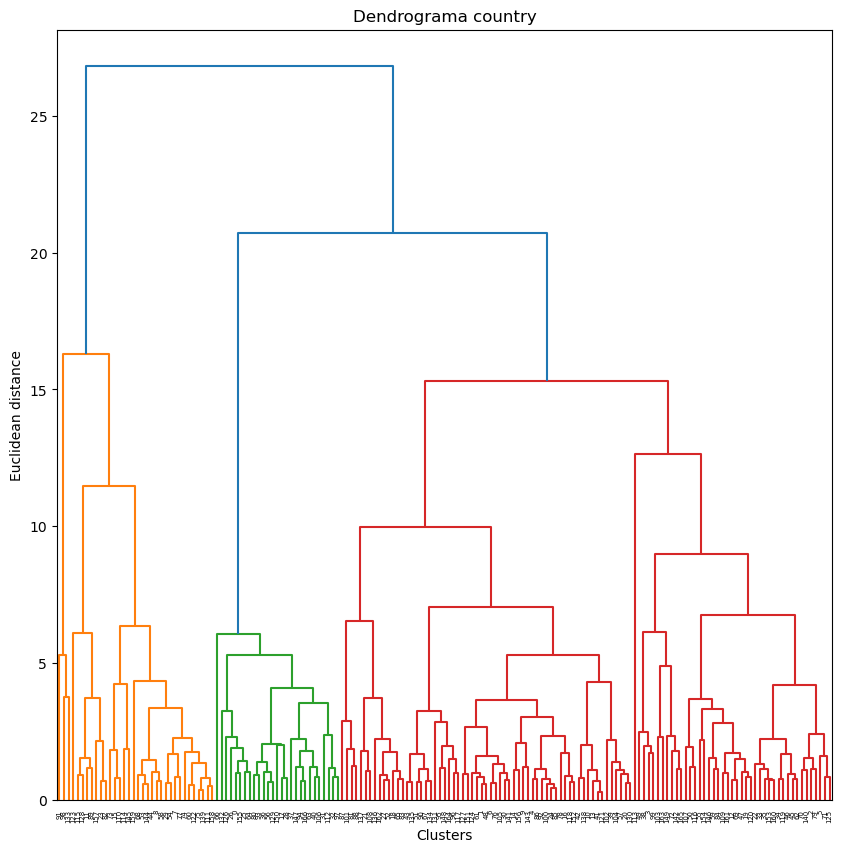

In [29]:
fig = plt.figure(figsize=(10,10))
dendrogram_plot = dendrogram(linkage(df_country_scaled, method='ward'))
plt.title('Dendrograma country')
plt.xlabel('Clusters')
plt.ylabel('Euclidean distance')
plt.show()

In [30]:
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
y_hc = hc.fit_predict(df_country_scaled)
print(silhouette_score(df_country_scaled,y_hc ))
df_country['hc'] = y_hc

0.3153134331018189


## DBSCAN

### PCA

In [31]:
# Importa la clase NearestNeighbors del módulo neighbors de la biblioteca scikit-learn.
# Esta clase se utiliza para encontrar los vecinos más cercanos de un conjunto de puntos.
from sklearn.neighbors import NearestNeighbors

# Crea una instancia del objeto NearestNeighbors.
# El parámetro `n_neighbors=2` le indica al algoritmo que encuentre los 2 vecinos más cercanos para cada punto.
# Esto incluye al punto mismo como uno de sus propios vecinos.
neighbors = NearestNeighbors(n_neighbors=2)

# Ajusta (entrena) el modelo con tus datos, que en este caso están en la variable `pca_data_standard`.
# El método `.fit()` indexa los puntos de datos en una estructura (como un KD-Tree o Ball-Tree)
# para que las búsquedas de vecinos cercanos se puedan realizar de manera muy eficiente.
neighbors_fit = neighbors.fit(pca_data_standard)

# Después de ajustar el modelo, este método encuentra los k-vecinos para cada punto en `pca_data_standard`.
# Devuelve dos arrays:
# - `distances`: Un array que contiene la distancia desde cada punto a sus 2 vecinos más cercanos.
# - `indices`: Un array que contiene los índices (la posición en el array original) de esos 2 vecinos más cercanos.
distances, indices = neighbors_fit.kneighbors(pca_data_standard)

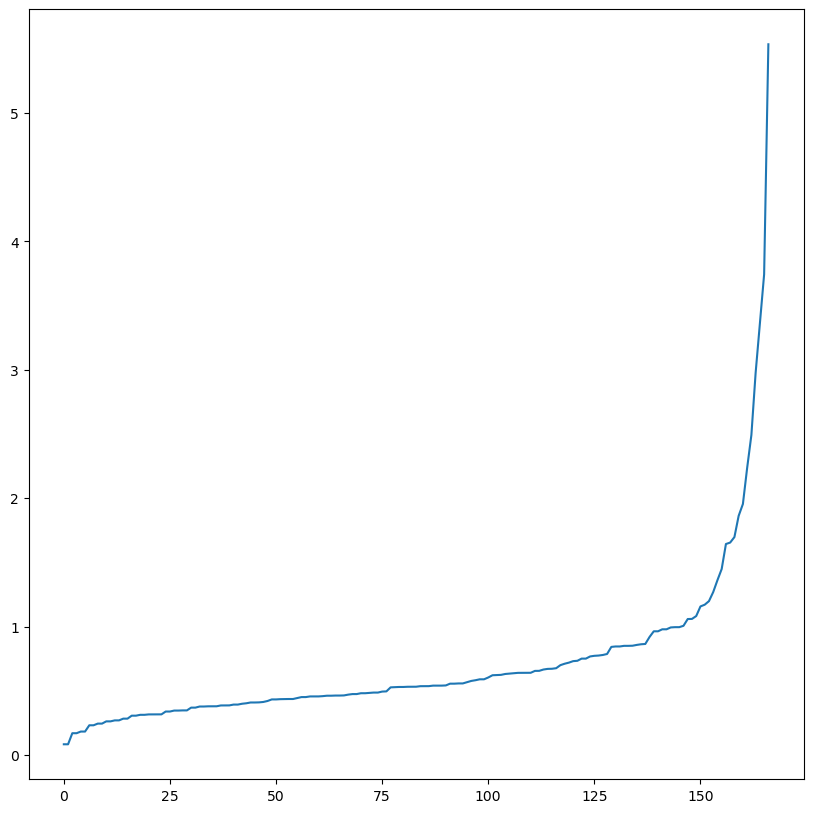

In [32]:
# distances = np.sort(distances, axis=0)
# Esta línea ordena la matriz 'distances' a lo largo del eje 0 (es decir, ordena
# los elementos de cada columna de menor a mayor de forma independiente).
distances = np.sort(distances, axis=0)

# distances = distances[:,1]
# De la matriz ya ordenada, esta línea selecciona todas las filas (indicado por ':')
# pero únicamente la columna en el índice 1 (la segunda columna). En muchos casos,
# la primera columna (índice 0) es la distancia de un punto a sí mismo (cero),
# por lo que la segunda columna representa la distancia al vecino más cercano.
distances = distances[:,1]

# fig = plt.figure(figsize=(10,10))
# Aquí se crea una nueva figura (un lienzo para dibujar) usando Matplotlib.
# El argumento 'figsize=(10,10)' establece el tamaño de la figura a 10 pulgadas
# de ancho por 10 pulgadas de alto, creando un lienzo cuadrado.
fig = plt.figure(figsize=(10,10))

# plt.plot(distances)
# Esta es la función que dibuja el gráfico. Como solo se le proporciona un
# conjunto de datos (el array 'distances', que ahora es unidimensional),
# Matplotlib los usará como los valores del eje Y. Para el eje X,
# automáticamente usará los índices de los elementos del array (0, 1, 2, ...).
# El resultado es un gráfico de las distancias ordenadas.
plt.plot(distances)


In [33]:
# Crea un rango de valores para el parámetro `eps` que se utilizará en el algoritmo DBSCAN.
# `eps` define la distancia máxima entre dos muestras para que se consideren en el mismo vecindario.
eps_values = np.arange(0.5, 2.0, 0.10)

# Crea un rango de valores para el parámetro `min_samples` que se utilizará en el algoritmo DBSCAN.
# `min_samples` es el número mínimo de muestras en un vecindario para que un punto se considere un núcleo.
min_samples = np.arange(3,12)

In [34]:
# Importa la función 'product' del módulo 'itertools'.
# Esta función se usa para calcular el producto cartesiano de dos o más listas,
# lo que es perfecto para generar todas las combinaciones posibles de parámetros.
from itertools import product

# Asumimos que 'eps_values' y 'min_samples' son listas que contienen los
# diferentes valores que queremos probar para los parámetros de DBSCAN.
# Por ejemplo: eps_values = [0.1, 0.5, 1.0], min_samples = [3, 5, 7]

# Crea una lista de tuplas. Cada tupla es una combinación de un valor de 'eps'
# y un valor de 'min_samples'. Esto nos da todos los pares de hiperparámetros
# que vamos a evaluar.
dbscan_paramns = list(product(eps_values, min_samples))

# Inicializa una lista vacía para almacenar el número de clústeres
# que se encuentren para cada combinación de parámetros.
no_of_clusters = []

# Inicializa una lista vacía para almacenar la puntuación de silueta (silhouette score)
# de cada resultado de clustering. Esta métrica mide qué tan bien definidos están los clústeres.
sil_score = []

# Inicia un bucle que recorrerá cada par de parámetros (p) en la lista 'dbscan_paramns'.
# En cada iteración, 'p' será una tupla como (valor_eps, valor_min_samples).
for p in dbscan_paramns:
    # Crea una instancia del algoritmo DBSCAN y lo entrena con los datos.
    # - eps=p[0]: Establece el parámetro 'eps' (distancia máxima entre dos muestras
    #   para que una se considere en la vecindad de la otra) con el primer valor de la tupla.
    # - min_samples=p[1]: Establece el parámetro 'min_samples' (el número de muestras
    #   en una vecindad para que un punto se considere como un punto central) con el segundo valor.
    # - .fit_predict(pca_data_standard): Entrena el modelo con los datos ('pca_data_standard')
    #   y devuelve las etiquetas de clúster para cada punto de datos.
    y_dbscan = DBSCAN(eps=p[0], min_samples=p[1]).fit_predict(pca_data_standard)

    # Inicia un bloque 'try' para manejar posibles errores al calcular la puntuación de silueta.
    try:
        # Calcula la puntuación de silueta para la agrupación actual y la añade a la lista 'sil_score'.
        # Esta puntuación falla si se encuentra menos de 2 clústeres (por ejemplo, si todos los
        # puntos son ruido o si todos caen en un solo clúster).
        sil_score.append(silhouette_score(pca_data_standard, y_dbscan))
    # Si ocurre un error en el bloque 'try' (por ejemplo, el error mencionado anteriormente)...
    except:
        # ...añade un 0 a la lista 'sil_score'. Esto nos permite continuar el bucle
        # sin que el programa se detenga.
        sil_score.append(0)

    # Calcula el número de clústeres únicos encontrados.
    # - np.unique(y_dbscan): Obtiene las etiquetas de clúster únicas (incluyendo -1 para el ruido).
    # - len(...): Cuenta cuántas etiquetas únicas hay.
    # - no_of_clusters.append(...): Añade este número a la lista 'no_of_clusters'.
    no_of_clusters.append(len(np.unique(y_dbscan)))



In [ ]:
# df_param_tunning = pd.DataFrame.from_records(dbscan_paramns, columns=['Eps','Min_samples'])
# Esta línea crea un nuevo DataFrame de pandas a partir de la lista 'dbscan_paramns'.
# - pd.DataFrame.from_records(): Es un método de pandas para crear un DataFrame a partir
#   de una lista de tuplas o registros (por ejemplo, [(0.5, 5), (0.5, 10), ...]).
# - dbscan_paramns: Son los datos de entrada.
# - columns=['Eps','Min_samples']: Asigna los nombres a las nuevas columnas. El primer
#   elemento de cada tupla en 'dbscan_paramns' irá a la columna 'Eps' y el segundo a 'Min_samples'.
# El DataFrame resultante se guarda en la variable 'df_param_tunning'.
df_param_tunning = pd.DataFrame.from_records(dbscan_paramns, columns=['Eps','Min_samples'])

# df_param_tunning['sil_score'] = sil_score
# Esta línea añade una nueva columna llamada 'sil_score' al DataFrame que acabamos de crear.
# Los valores para esta columna se toman directamente de la lista 'sil_score'.
# Pandas alinea automáticamente los elementos de la lista con las filas del DataFrame
# basándose en su índice.
df_param_tunning['sil_score'] = sil_score

# df_param_tunning['n_clusters'] = no_of_clusters
# De forma similar a la línea anterior, esto añade otra columna nueva llamada 'n_clusters'.
# Los valores para esta columna se toman de la lista 'no_of_clusters'.
df_param_tunning['n_clusters'] = no_of_clusters


In [ ]:
# pivot_1 = pd.pivot_table(df_param_tunning, values='sil_score', columns='Eps', index='Min_samples')
# Esta línea crea una "tabla dinámica" (pivot table) a partir del DataFrame 'df_param_tunning'.
# El objetivo es reorganizar los datos para que sean más fáciles de visualizar.
# - pd.pivot_table: La función de pandas que realiza esta operación.
# - df_param_tunning: El DataFrame de origen que contiene los datos en formato largo.
# - values='sil_score': Especifica que los valores que llenarán las celdas de la nueva
#   tabla serán los de la columna 'sil_score'.
# - columns='Eps': Indica que las columnas de la nueva tabla se crearán a partir de los
#   valores únicos de la columna 'Eps'.
# - index='Min_samples': Indica que las filas (el índice) de la nueva tabla se crearán
#   a partir de los valores únicos de la columna 'Min_samples'.
# El resultado es una tabla donde las filas son los valores de 'Min_samples', las columnas
# son los valores de 'Eps', y el contenido de cada celda es la 'sil_score' correspondiente.
pivot_1 = pd.pivot_table(df_param_tunning, values='sil_score', columns='Eps', index='Min_samples')

# pivot_2 = pd.pivot_table(df_param_tunning, values='n_clusters', columns='Eps', index='Min_samples')
#   tabla serán los de la columna 'sil_score'.
# - columns='Eps': Indica que las columnas de la nueva tabla se crearán a partir de los
#   valores únicos de la columna 'Eps'.
# - index='Min_samples': Indica que las filas (el índice) de la nueva tabla se crearán
#   a partir de los valores únicos de la columna 'Min_samples'.
# El resultado es una tabla donde las filas son los valores de 'Min_samples', las columnas
# son los valores de 'Eps', y el contenido de cada celda es la 'sil_score' correspondiente.
pivot_1 = pd.pivot_table(df_param_tunning, values='sil_score', columns='Eps', index='Min_samples')

# pivot_2 = pd.pivot_table(df_param_tunning, values='n_clusters', columns='Eps', index='Min_samples')
# Esta línea hace exactamente lo mismo que la anterior, pero para una métrica diferente.
# Crea una segunda tabla dinámica con la misma estructura (filas de 'Min_samples' y
# columnas de 'Eps').
# - values='n_clusters': La única diferencia es que, en este caso, los valores que
#   llenarán las celdas de la tabla serán los de la columna 'n_clusters' (número de clústeres).
# Esto te da una segunda matriz que muestra cuántos clústeres se generaron para cada
# combinación de 'Eps' y 'Min_samples'.
pivot_2 = pd.pivot_table(df_param_tunning, values='n_clusters', columns='Eps', index='Min_samples')


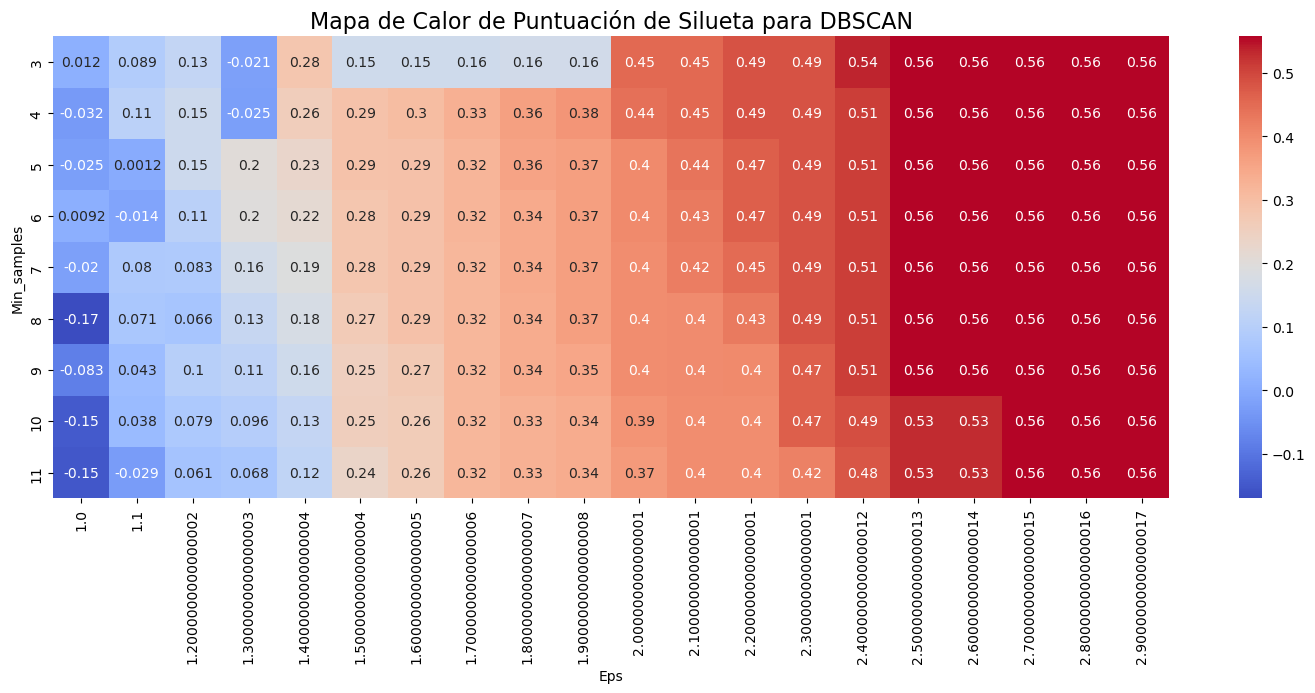

In [55]:
# fig, ax = plt.subplots(figsize=(18,6))
# Esta línea crea una figura y un conjunto de subplots (ejes) usando Matplotlib.
# - plt.subplots(): Es una función que crea una figura y una cuadrícula de subplots en un solo paso.
# - fig: Es el objeto de la figura completa, como un lienzo en blanco.
# - ax: Es el objeto del subplot (o "ejes"), que es el área específica donde se dibujará el gráfico.
# - figsize=(18,6): Establece el tamaño de la figura a 18 pulgadas de ancho por 6 de alto.
fig, ax = plt.subplots(figsize=(18,6))

# Añadir un título al gráfico usando el objeto 'ax'
ax.set_title('Mapa de Calor de Puntuación de Silueta para DBSCAN', fontsize=16)


# sns.heatmap(pivot_1, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)
# Esta es la línea principal que dibuja el mapa de calor usando la librería Seaborn.
# - sns.heatmap(): La función para crear el mapa de calor.
# - pivot_1: Los datos a graficar. Debe ser una matriz 2D, como la tabla dinámica que preparamos.
# - annot=True: 'annot' es abreviatura de 'annotate' (anotar). Al ponerlo en True, se escribe
#   el valor de cada celda directamente sobre el mapa de calor.
# - annot_kws={'size':10}: 'kws' es abreviatura de 'keyword arguments' (argumentos de palabra clave).
#   Esto permite personalizar las anotaciones. Aquí, se establece el tamaño de la fuente a 10.
# - cmap='coolwarm': 'cmap' significa 'colormap' (mapa de colores). 'coolwarm' es una paleta de colores
#   que va de azul (frío, para valores bajos) a rojo (cálido, para valores altos).
# - ax=ax: Le indica a Seaborn que dibuje este mapa de calor en el subplot 'ax' que creamos antes.
sns.heatmap(pivot_1, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)

# plt.show()
# Esta función de Matplotlib muestra la figura que se ha estado creando en memoria.
# Sin esta línea, en muchos entornos (como al ejecutar un script), el gráfico no aparecería en pantalla.
plt.show()


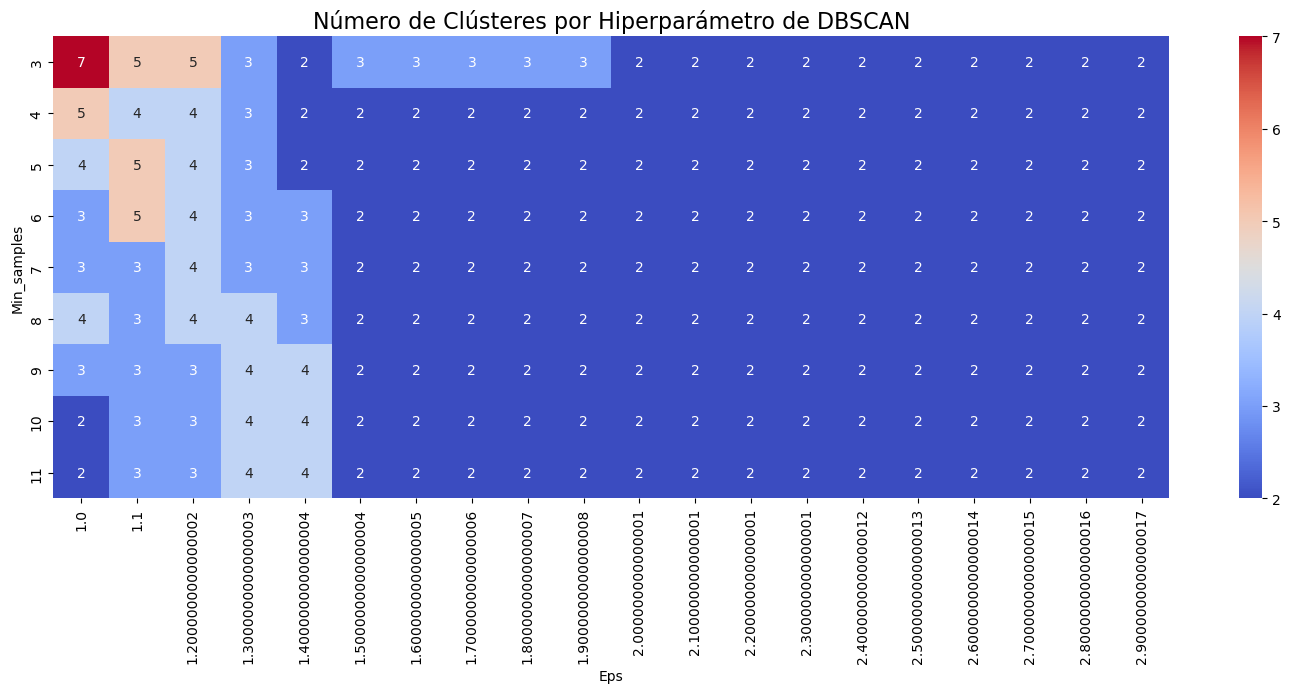

In [59]:
# fig, ax = plt.subplots(figsize=(18,6))
# Esta línea crea una figura (el lienzo general) y un subplot o "ejes" (el área de dibujo)
# usando Matplotlib.
# - fig: El objeto de la figura completa.
# - ax: El objeto de los ejes donde se dibujará el gráfico.
# - figsize=(18,6): Define el tamaño de la figura en 18 pulgadas de ancho por 6 de alto.
fig, ax = plt.subplots(figsize=(18,6))

# Añadir un título claro y descriptivo
ax.set_title('Número de Clústeres por Hiperparámetro de DBSCAN', fontsize=16)


# sns.heatmap(pivot_2, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)
# Esta es la función principal que dibuja el mapa de calor usando la librería Seaborn.
# - sns.heatmap(): La función para crear el mapa de calor.
# - pivot_2: Los datos a graficar, en este caso, la matriz con el número de clústeres.
# - annot=True: Le indica a Seaborn que anote cada celda con su valor numérico.
# - annot_kws={'size':10}: Argumentos de palabra clave para las anotaciones. Aquí se usa
#   para establecer el tamaño de la fuente de los números en 10.
# - cmap='coolwarm': Define el mapa de colores. 'coolwarm' va de azul (valores bajos) a
#   rojo (valores altos).
# - ax=ax: Especifica que el mapa de calor debe dibujarse en los ejes 'ax' que creamos
#   previamente. Esta es una excelente práctica para manejar gráficos complejos.
sns.heatmap(pivot_2, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)

# plt.show()
# Esta función de Matplotlib renderiza y muestra la figura en la pantalla. Sin esta llamada,
# en muchos entornos de ejecución de scripts, el gráfico no sería visible.
plt.show()


In [60]:
# dbscan_train = DBSCAN(eps=1.2, min_samples=3)
# Esta línea crea una instancia del algoritmo de clustering DBSCAN con los
# hiperparámetros que se determinaron como óptimos en el análisis anterior.
# - DBSCAN: El constructor del modelo.
# - eps=1.2: Define la distancia máxima entre dos puntos para que uno sea
#   considerado vecino del otro. Un valor de 1.2 fue probablemente elegido
#   tras analizar el "gráfico de codo" o el mapa de calor.
# - min_samples=3: Define el número mínimo de puntos que deben estar dentro
#   del radio 'eps' para que un punto sea considerado un "punto central" (core point).
dbscan_train = DBSCAN(eps=1.2, min_samples=3)

# y_dbscan = dbscan_train.fit_predict(pca_data_standard)
# Aquí se entrena el modelo y se asignan los clústeres en un solo paso.
# - .fit_predict(pca_data_standard): Este método entrena el modelo DBSCAN con los
#   datos ('pca_data_standard') y devuelve un array donde cada elemento es la
#   etiqueta del clúster asignado a cada punto de datos.
# - Los puntos que no pertenecen a ningún clúster (ruido) reciben la etiqueta -1.
# - El resultado se guarda en la variable 'y_dbscan'.
y_dbscan = dbscan_train.fit_predict(pca_data_standard)

# print(silhouette_score(pca_data_standard, y_dbscan))
# Esta línea calcula y muestra la Puntuación de Silueta (Silhouette Score) para
# evaluar la calidad del clustering resultante.
# - silhouette_score(...): Es una métrica que mide qué tan bien definidos están los
#   clústeres. Un valor cercano a 1 indica clústeres densos y bien separados.
#   Un valor cercano a 0 indica clústeres superpuestos, y un valor negativo
#   indica que los puntos pueden haber sido asignados al clúster incorrecto.
print(silhouette_score(pca_data_standard, y_dbscan))

# df_country['dbscan_pca'] = y_dbscan
# Finalmente, esta línea añade los resultados del clustering (las etiquetas de clúster)
# como una nueva columna al DataFrame original 'df_country'.
# - df_country['dbscan_pca']: Crea una nueva columna llamada 'dbscan_pca'.
# - = y_dbscan: Asigna el array de etiquetas de clúster a esta nueva columna.
# Esto es muy útil para poder analizar y visualizar qué países (o registros)
# han caído en cada clúster.
df_country['dbscan_pca'] = y_dbscan


0.18591175730784368


### Sin PCA

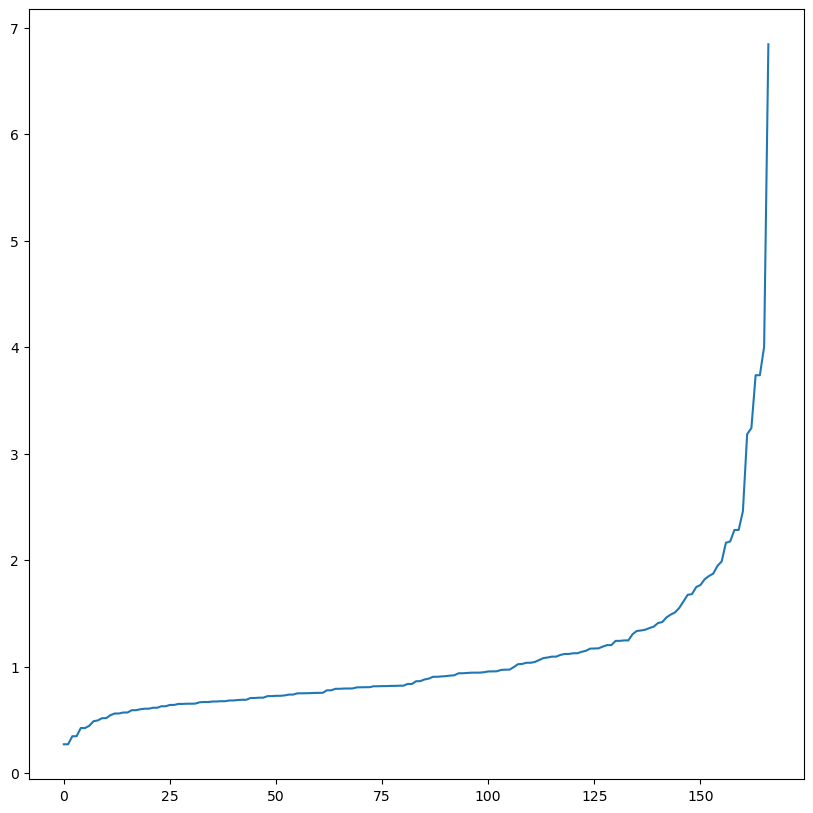

In [61]:
# neighbors = NearestNeighbors(n_neighbors=2)
# Esta línea crea una instancia del algoritmo NearestNeighbors.
# - n_neighbors=2: Se configura para encontrar los 2 vecinos más cercanos para cada punto.
#   Se usa '2' porque el vecino más cercano de cualquier punto es siempre él mismo (con distancia 0).
#   Por lo tanto, el segundo vecino más cercano es, en realidad, el primer vecino "real".
neighbors = NearestNeighbors(n_neighbors=2)

# neighbors_fit = neighbors.fit(df_country_scaled)
# Aquí se "entrena" el modelo NearestNeighbors con los datos escalados ('df_country_scaled').
# En realidad, no es un entrenamiento en el sentido tradicional, sino que el algoritmo
# organiza los datos en una estructura eficiente (como un k-d tree) para poder
# realizar búsquedas de vecinos de manera muy rápida.
neighbors_fit = neighbors.fit(df_country_scaled)

# distances, indices = neighbors_fit.kneighbors(df_country_scaled)
# Esta línea ejecuta la búsqueda. Para cada punto en 'df_country_scaled', encuentra
# los 2 vecinos más cercanos que configuramos antes.
# - distances: Devuelve una matriz con las distancias a esos vecinos.
# - indices: Devuelve una matriz con los índices (la posición en el dataset) de esos vecinos.
distances, indices = neighbors_fit.kneighbors(df_country_scaled)

# distances = np.sort(distances, axis=0)
# Ordena la matriz de distancias a lo largo del eje 0 (es decir, ordena cada columna
# de menor a mayor de forma independiente).
distances = np.sort(distances, axis=0)

# distances = distances[:,1]
# De la matriz de distancias, esta línea selecciona todas las filas (indicado por ':')
# pero únicamente la columna en el índice 1 (la segunda columna). Esta columna contiene
# las distancias al vecino más cercano "real" para cada punto (recordemos que la primera
# columna, índice 0, contenía la distancia a sí mismo).
distances = distances[:,1]

# fig = plt.figure(figsize=(10,10))
# Crea una nueva figura o "lienzo" de Matplotlib para dibujar el gráfico,
# con un tamaño de 10x10 pulgadas.
fig = plt.figure(figsize=(10,10))

# plt.plot(distances)
# Dibuja un gráfico de líneas. Como solo se le pasa un array ('distances'),
# Matplotlib lo usa para los valores del eje Y, y para el eje X usa los índices
# de los puntos (de 0 al número total de puntos). El resultado es un gráfico
# de las distancias al vecino más cercano, ordenadas de menor a mayor.
plt.plot(distances)


In [ ]:
# eps_values = np.arange(1, 3.0, 0.10)
# Esta línea crea un array de NumPy que contiene una secuencia de valores para el parámetro 'eps'.
# - np.arange(): Es una función de NumPy que genera valores espaciados uniformemente dentro de un intervalo.
# - 1: Es el valor de inicio de la secuencia (incluido).
# - 3.0: Es el valor final de la secuencia (excluido). La secuencia llegará hasta, pero no incluirá, 3.0.
# - 0.10: Es el paso o incremento entre cada valor consecutivo.
# El resultado es un array con los valores [1.0, 1.1, 1.2, ..., 2.9], que son los candidatos
# para el hiperparámetro 'eps' que se van a evaluar.
eps_values = np.arange(1, 3.0, 0.10)

# min_samples = np.arange(3, 12)
# Esta línea crea otro array de NumPy para los valores del parámetro 'min_samples'.
# - np.arange(3, 12): Genera una secuencia de números enteros.
# - 3: El valor de inicio (incluido).
# - 12: El valor final (excluido).
# - Como no se especifica un tercer argumento para el paso, NumPy usa el valor por defecto, que es 1.
# El resultado es un array de enteros: [3, 4, 5, 6, 7, 8, 9, 10, 11].
# Estos son los candidatos para el hiperparámetro 'min_samples'.
min_samples = np.arange(3, 12)


In [ ]:
# Importa la función 'product' del módulo 'itertools'.
# Esta función es muy útil para generar el producto cartesiano de varias listas,
# es decir, crea todas las combinaciones posibles entre los elementos de esas listas.
from itertools import product 

# Asumimos que 'eps_values' y 'min_samples' son listas o arrays que contienen
# los diferentes valores que queremos probar para los parámetros de DBSCAN.

# Crea una lista de tuplas. Cada tupla contiene una combinación única de un valor
# de 'eps_values' y un valor de 'min_samples'. Esto genera la "parrilla" (grid)
# completa de todos los hiperparámetros que se van a evaluar.
dbscan_paramns = list(product(eps_values, min_samples))

# Inicializa una lista vacía para guardar el número de clústeres que se
# encuentren para cada combinación de parámetros.
no_of_clusters = []

# Inicializa una lista vacía para guardar la puntuación de silueta (silhouette score)
# de cada resultado. Esta métrica evalúa la calidad de los clústeres formados.
sil_score = []

# Inicia un bucle 'for' que itera sobre cada par de parámetros (p) en la lista 'dbscan_paramns'.
# En cada iteración, 'p' será una tupla, por ejemplo: (1.2, 3).
for p in dbscan_paramns:
    # Crea una instancia de DBSCAN, la entrena con los datos y predice los clústeres.
    # - eps=p[0]: Asigna el primer elemento de la tupla 'p' al parámetro 'eps'.
    # - min_samples=p[1]: Asigna el segundo elemento de la tupla 'p' al parámetro 'min_samples'.
    # - .fit_predict(df_country_scaled): Entrena el modelo con los datos y devuelve un array
    #   con la etiqueta del clúster asignado a cada punto de datos.
    y_dbscan = DBSCAN(eps=p[0], min_samples=p[1]).fit_predict(df_country_scaled)
    
    # Inicia un bloque 'try' para manejar errores que puedan ocurrir al calcular la puntuación.
    try:
        # Intenta calcular la puntuación de silueta. Esta métrica requiere al menos 2 clústeres
        # y menos de n_samples-1 clústeres. Si DBSCAN encuentra solo un clúster o solo ruido,
        # esta función lanzará un error.
        sil_score.append(silhouette_score(df_country_scaled, y_dbscan))
    # Si se produce un error (generalmente un ValueError) en el bloque 'try'...
    except:
        # ...en lugar de detener el programa, se añade un 0 a la lista 'sil_score'.
        # Esto trata a las combinaciones que no producen clústeres válidos como resultados de baja calidad.
        sil_score.append(0)    
    
    # Calcula el número de clústeres únicos encontrados por DBSCAN.
    # - np.unique(y_dbscan): Obtiene las etiquetas de clúster únicas (incluyendo la etiqueta -1 para el ruido).
    # - len(...): Cuenta cuántas etiquetas únicas hay.
    # - .append(...): Añade este conteo a la lista 'no_of_clusters'.
    no_of_clusters.append(len(np.unique(y_dbscan)))


In [62]:
# df_param_tunning = pd.DataFrame.from_records(dbscan_paramns, columns=['Eps','Min_samples'])
# Esta línea crea un nuevo DataFrame de pandas a partir de la lista 'dbscan_paramns'.
# - pd.DataFrame.from_records(): Es un método de pandas para crear un DataFrame a partir
#   de una lista de tuplas o registros (por ejemplo, [(0.5, 5), (0.5, 10), ...]).
# - dbscan_paramns: Son los datos de entrada.
# - columns=['Eps','Min_samples']: Asigna los nombres a las nuevas columnas. El primer
#   elemento de cada tupla en 'dbscan_paramns' irá a la columna 'Eps' y el segundo a 'Min_samples'.
# El DataFrame resultante se guarda en la variable 'df_param_tunning'.
df_param_tunning = pd.DataFrame.from_records(dbscan_paramns, columns=['Eps','Min_samples'])

# df_param_tunning['sil_score'] = sil_score
# Esta línea añade una nueva columna llamada 'sil_score' al DataFrame que acabamos de crear.
# Los valores para esta columna se toman directamente de la lista 'sil_score'.
# Pandas alinea automáticamente los elementos de la lista con las filas del DataFrame
# basándose en su índice.
df_param_tunning['sil_score'] = sil_score

# df_param_tunning['n_clusters'] = no_of_clusters
# De forma similar a la línea anterior, esto añade otra columna nueva llamada 'n_clusters'.
# Los valores para esta columna se toman de la lista 'no_of_clusters'.
df_param_tunning['n_clusters'] = no_of_clusters


In [63]:
# pivot_1 = pd.pivot_table(df_param_tunning, values='sil_score', columns='Eps', index='Min_samples')
# Esta línea crea una "tabla dinámica" (pivot table) a partir del DataFrame 'df_param_tunning'.
# El objetivo es reorganizar los datos para que sean más fáciles de visualizar.
# - pd.pivot_table: La función de pandas que realiza esta operación.
# - df_param_tunning: El DataFrame de origen que contiene los datos en formato largo.
# - values='sil_score': Especifica que los valores que llenarán las celdas de la nueva
#   tabla serán los de la columna 'sil_score'.
# - columns='Eps': Indica que las columnas de la nueva tabla se crearán a partir de los
#   valores únicos de la columna 'Eps'.
# - index='Min_samples': Indica que las filas (el índice) de la nueva tabla se crearán
#   a partir de los valores únicos de la columna 'Min_samples'.
# El resultado es una tabla donde las filas son los valores de 'Min_samples', las columnas
# son los valores de 'Eps', y el contenido de cada celda es la 'sil_score' correspondiente.
pivot_1 = pd.pivot_table(df_param_tunning, values='sil_score', columns='Eps', index='Min_samples')

# pivot_2 = pd.pivot_table(df_param_tunning, values='n_clusters', columns='Eps', index='Min_samples')
# Esta línea hace exactamente lo mismo que la anterior, pero para una métrica diferente.
# Crea una segunda tabla dinámica con la misma estructura (filas de 'Min_samples' y
# columnas de 'Eps').
# - values='n_clusters': La única diferencia es que, en este caso, los valores que
#   llenarán las celdas de la tabla serán los de la columna 'n_clusters' (número de clústeres).
# El resultado es una tabla donde las filas son los valores de 'Min_samples', las columnas
# son los valores de 'Eps', y el contenido de cada celda es la 'n_clusters' correspondiente.
pivot_1 = pd.pivot_table(df_param_tunning, values='sil_score', columns='Eps', index='Min_samples')

# pivot_2 = pd.pivot_table(df_param_tunning, values='n_clusters', columns='Eps', index='Min_samples')
# Esta línea hace exactamente lo mismo que la anterior, pero para una métrica diferente.
# Crea una segunda tabla dinámica con la misma estructura (filas de 'Min_samples' y
# columnas de 'Eps').
# - values='n_clusters': La única diferencia es que, en este caso, los valores que
#   llenarán las celdas de la tabla serán los de la columna 'n_clusters' (número de clústeres).
# Esto te da una segunda matriz que muestra cuántos clústeres se generaron para cada
# combinación de 'Eps' y 'Min_samples'.
pivot_2 = pd.pivot_table(df_param_tunning, values='n_clusters', columns='Eps', index='Min_samples')


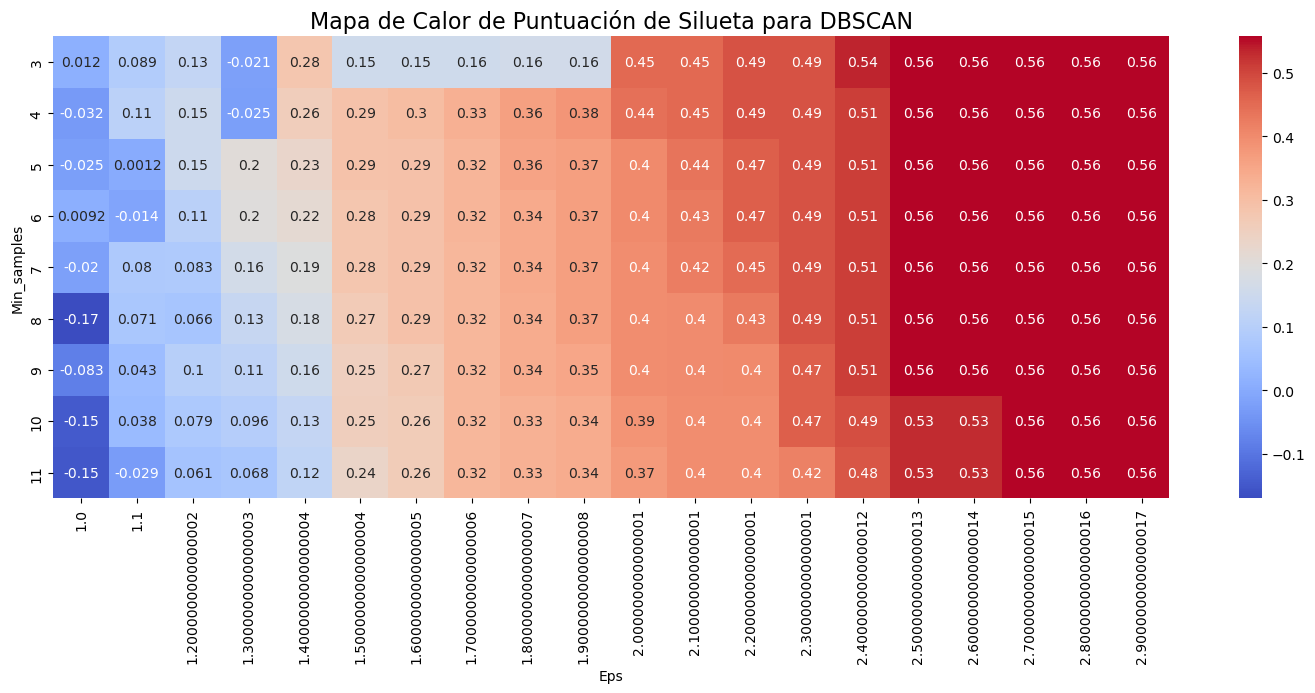

In [64]:
# fig, ax = plt.subplots(figsize=(18,6))
# Esta línea crea una figura y un conjunto de subplots (ejes) usando Matplotlib.
# - plt.subplots(): Es una función que crea una figura y una cuadrícula de subplots en un solo paso.
# - fig: Es el objeto de la figura completa, como un lienzo en blanco.
# - ax: Es el objeto del subplot (o "ejes"), que es el área específica donde se dibujará el gráfico.
# - figsize=(18,6): Establece el tamaño de la figura a 18 pulgadas de ancho por 6 de alto.
fig, ax = plt.subplots(figsize=(18,6))

# Añadir un título al gráfico usando el objeto 'ax'
ax.set_title('Mapa de Calor de Puntuación de Silueta para DBSCAN', fontsize=16)

# sns.heatmap(pivot_1, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)
# Esta es la línea principal que dibuja el mapa de calor usando la librería Seaborn.
# - sns.heatmap(): La función para crear el mapa de calor.
# - pivot_1: Los datos a graficar. Debe ser una matriz 2D, como la tabla dinámica que preparamos.
# - annot=True: 'annot' es abreviatura de 'annotate' (anotar). Al ponerlo en True, se escribe
#   el valor de cada celda directamente sobre el mapa de calor.
# - annot_kws={'size':10}: 'kws' es abreviatura de 'keyword arguments' (argumentos de palabra clave).
#   Esto permite personalizar las anotaciones. Aquí, se establece el tamaño de la fuente a 10.
# - cmap='coolwarm': 'cmap' significa 'colormap' (mapa de colores). 'coolwarm' es una paleta de colores
#   que va de azul (frío, para valores bajos) a rojo (cálido, para valores altos).
# - ax=ax: Le indica a Seaborn que dibuje este mapa de calor en el subplot 'ax' que creamos antes.
sns.heatmap(pivot_1, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)

# plt.show()
# Esta función de Matplotlib muestra la figura que se ha estado creando en memoria.
# Sin esta línea, en muchos entornos (como al ejecutar un script), el gráfico no aparecería en pantalla.
plt.show()


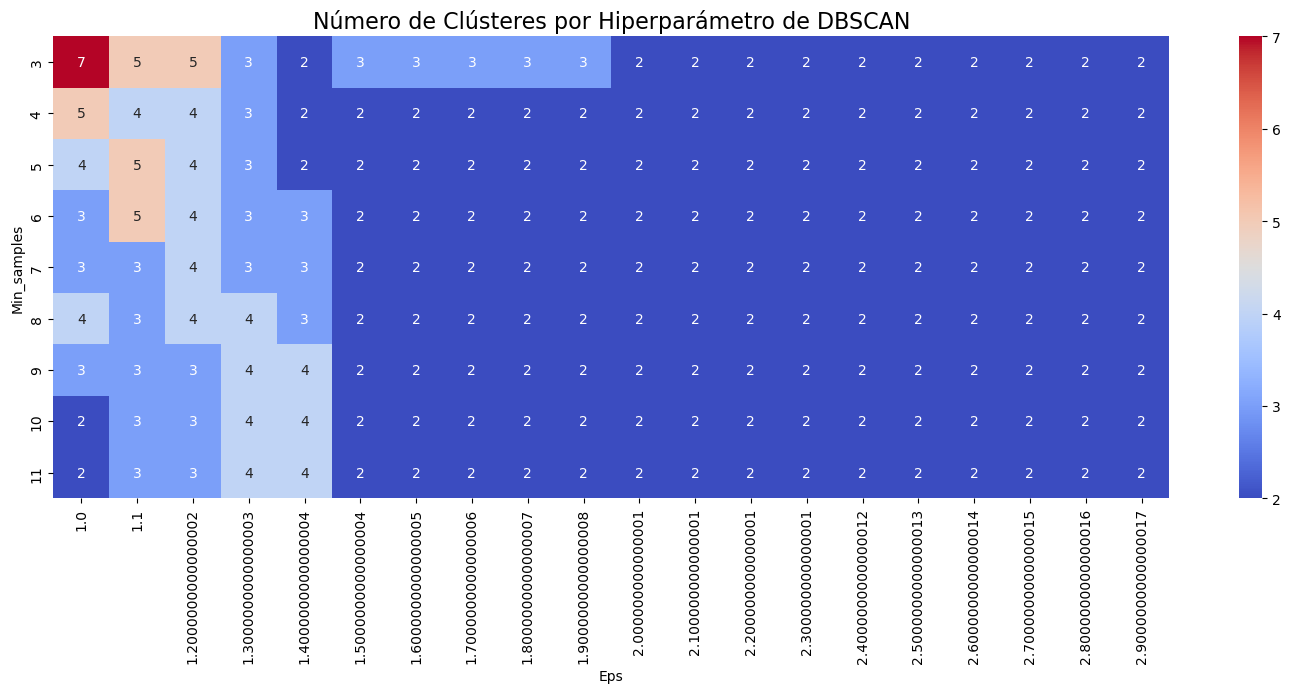

In [65]:
# fig, ax = plt.subplots(figsize=(18,6))
# Esta línea crea una figura (el lienzo general) y un subplot o "ejes" (el área de dibujo)
# usando Matplotlib.
# - fig: El objeto de la figura completa.
# - ax: El objeto de los ejes donde se dibujará el gráfico.
# - figsize=(18,6): Define el tamaño de la figura en 18 pulgadas de ancho por 6 de alto.
fig, ax = plt.subplots(figsize=(18,6))

# Añadir un título claro y descriptivo
ax.set_title('Número de Clústeres por Hiperparámetro de DBSCAN', fontsize=16)

# sns.heatmap(pivot_2, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)
# Esta es la función principal que dibuja el mapa de calor usando la librería Seaborn.
# - sns.heatmap(): La función para crear el mapa de calor.
# - pivot_2: Los datos a graficar, en este caso, la matriz con el número de clústeres.
# - annot=True: Le indica a Seaborn que anote cada celda con su valor numérico.
# - annot_kws={'size':10}: Argumentos de palabra clave para las anotaciones. Aquí se usa
#   para establecer el tamaño de la fuente de los números en 10.
# - cmap='coolwarm': Define el mapa de colores. 'coolwarm' va de azul (valores bajos) a
#   rojo (valores altos).
# - ax=ax: Especifica que el mapa de calor debe dibujarse en los ejes 'ax' que creamos
#   previamente. Esta es una excelente práctica para manejar gráficos complejos.
sns.heatmap(pivot_2, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)

# plt.show()
# Esta función de Matplotlib renderiza y muestra la figura en la pantalla. Sin esta llamada,
# en muchos entornos de ejecución de scripts, el gráfico no sería visible.
plt.show()


In [47]:
# dbscan_train = DBSCAN(eps=1.7, min_samples=3)
# Esta línea crea una instancia del algoritmo de clustering DBSCAN.
# Se le pasan los hiperparámetros que probablemente se determinaron como los mejores
# durante la fase de análisis y ajuste.
# - eps=1.7: Define la distancia máxima (epsilon) entre dos puntos para que se consideren vecinos.
# - min_samples=3: Define el número mínimo de vecinos que un punto debe tener en su radio 'eps'
#   para ser considerado un "punto central" (core point) y no ruido.
dbscan_train = DBSCAN(eps=1.7, min_samples=3)

# y_dbscan = dbscan_train.fit_predict(df_country_scaled)
# Aquí se entrena el modelo DBSCAN y se asignan los clústeres en un solo paso.
# - .fit_predict(df_country_scaled): Este método aplica el algoritmo a los datos.
#   Primero, "aprende" la estructura de los clústeres y luego devuelve un array
#   donde cada elemento es la etiqueta del clúster asignado a cada punto de datos.
# - Las etiquetas son números enteros (0, 1, 2, ...). Los puntos considerados "ruido"
#   (que no pertenecen a ningún clúster) reciben la etiqueta -1.
# - El resultado se guarda en la variable 'y_dbscan'.
y_dbscan = dbscan_train.fit_predict(df_country_scaled)

# print(silhouette_score(df_country_scaled, y_dbscan))
# Esta línea calcula y muestra en pantalla la Puntuación de Silueta (Silhouette Score).
# - silhouette_score(...): Es una métrica que evalúa la calidad del clustering. Mide qué tan
#   bien separados están los clústeres y qué tan densos son.
# - Un valor cercano a +1 indica clústeres excelentes, bien definidos y separados.
# - Un valor cercano a 0 indica clústeres superpuestos.
# - Un valor negativo indica que los puntos podrían haber sido asignados al clúster incorrecto.
print(silhouette_score(df_country_scaled, y_dbscan))

# df_country['dbscan_cluster'] = y_dbscan
# Esta es una de las líneas más importantes para el análisis. Añade los resultados del
# clustering (las etiquetas de 'y_dbscan') como una nueva columna al DataFrame original.
# - df_country['dbscan_cluster']: Crea una nueva columna con el nombre 'dbscan_cluster'.
# - = y_dbscan: Asigna el array de etiquetas a esta nueva columna.
# Esto te permite ahora filtrar, agrupar y analizar las características de los países
# que pertenecen a cada clúster.
df_country['dbscan_cluster'] = y_dbscan


0.1563549566374231


In [66]:
df_country

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_pca,k_means,hc_pca,hc,dbscan_pca,dbscan_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,1,1,0,0,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,3,0,0,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,3,1,0,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,1,1,0,-1,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2,3,0,0,0,0
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2,3,1,0,-1,-1
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2,3,0,0,0,0
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1,1,1,0,0,0


## Evaluación de resultados

In [67]:
df_country.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'k_means_pca',
       'k_means', 'hc_pca', 'hc', 'dbscan_pca', 'dbscan_cluster'],
      dtype='object')

In [50]:
df_country[['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'k_means_pca']]

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_pca
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1


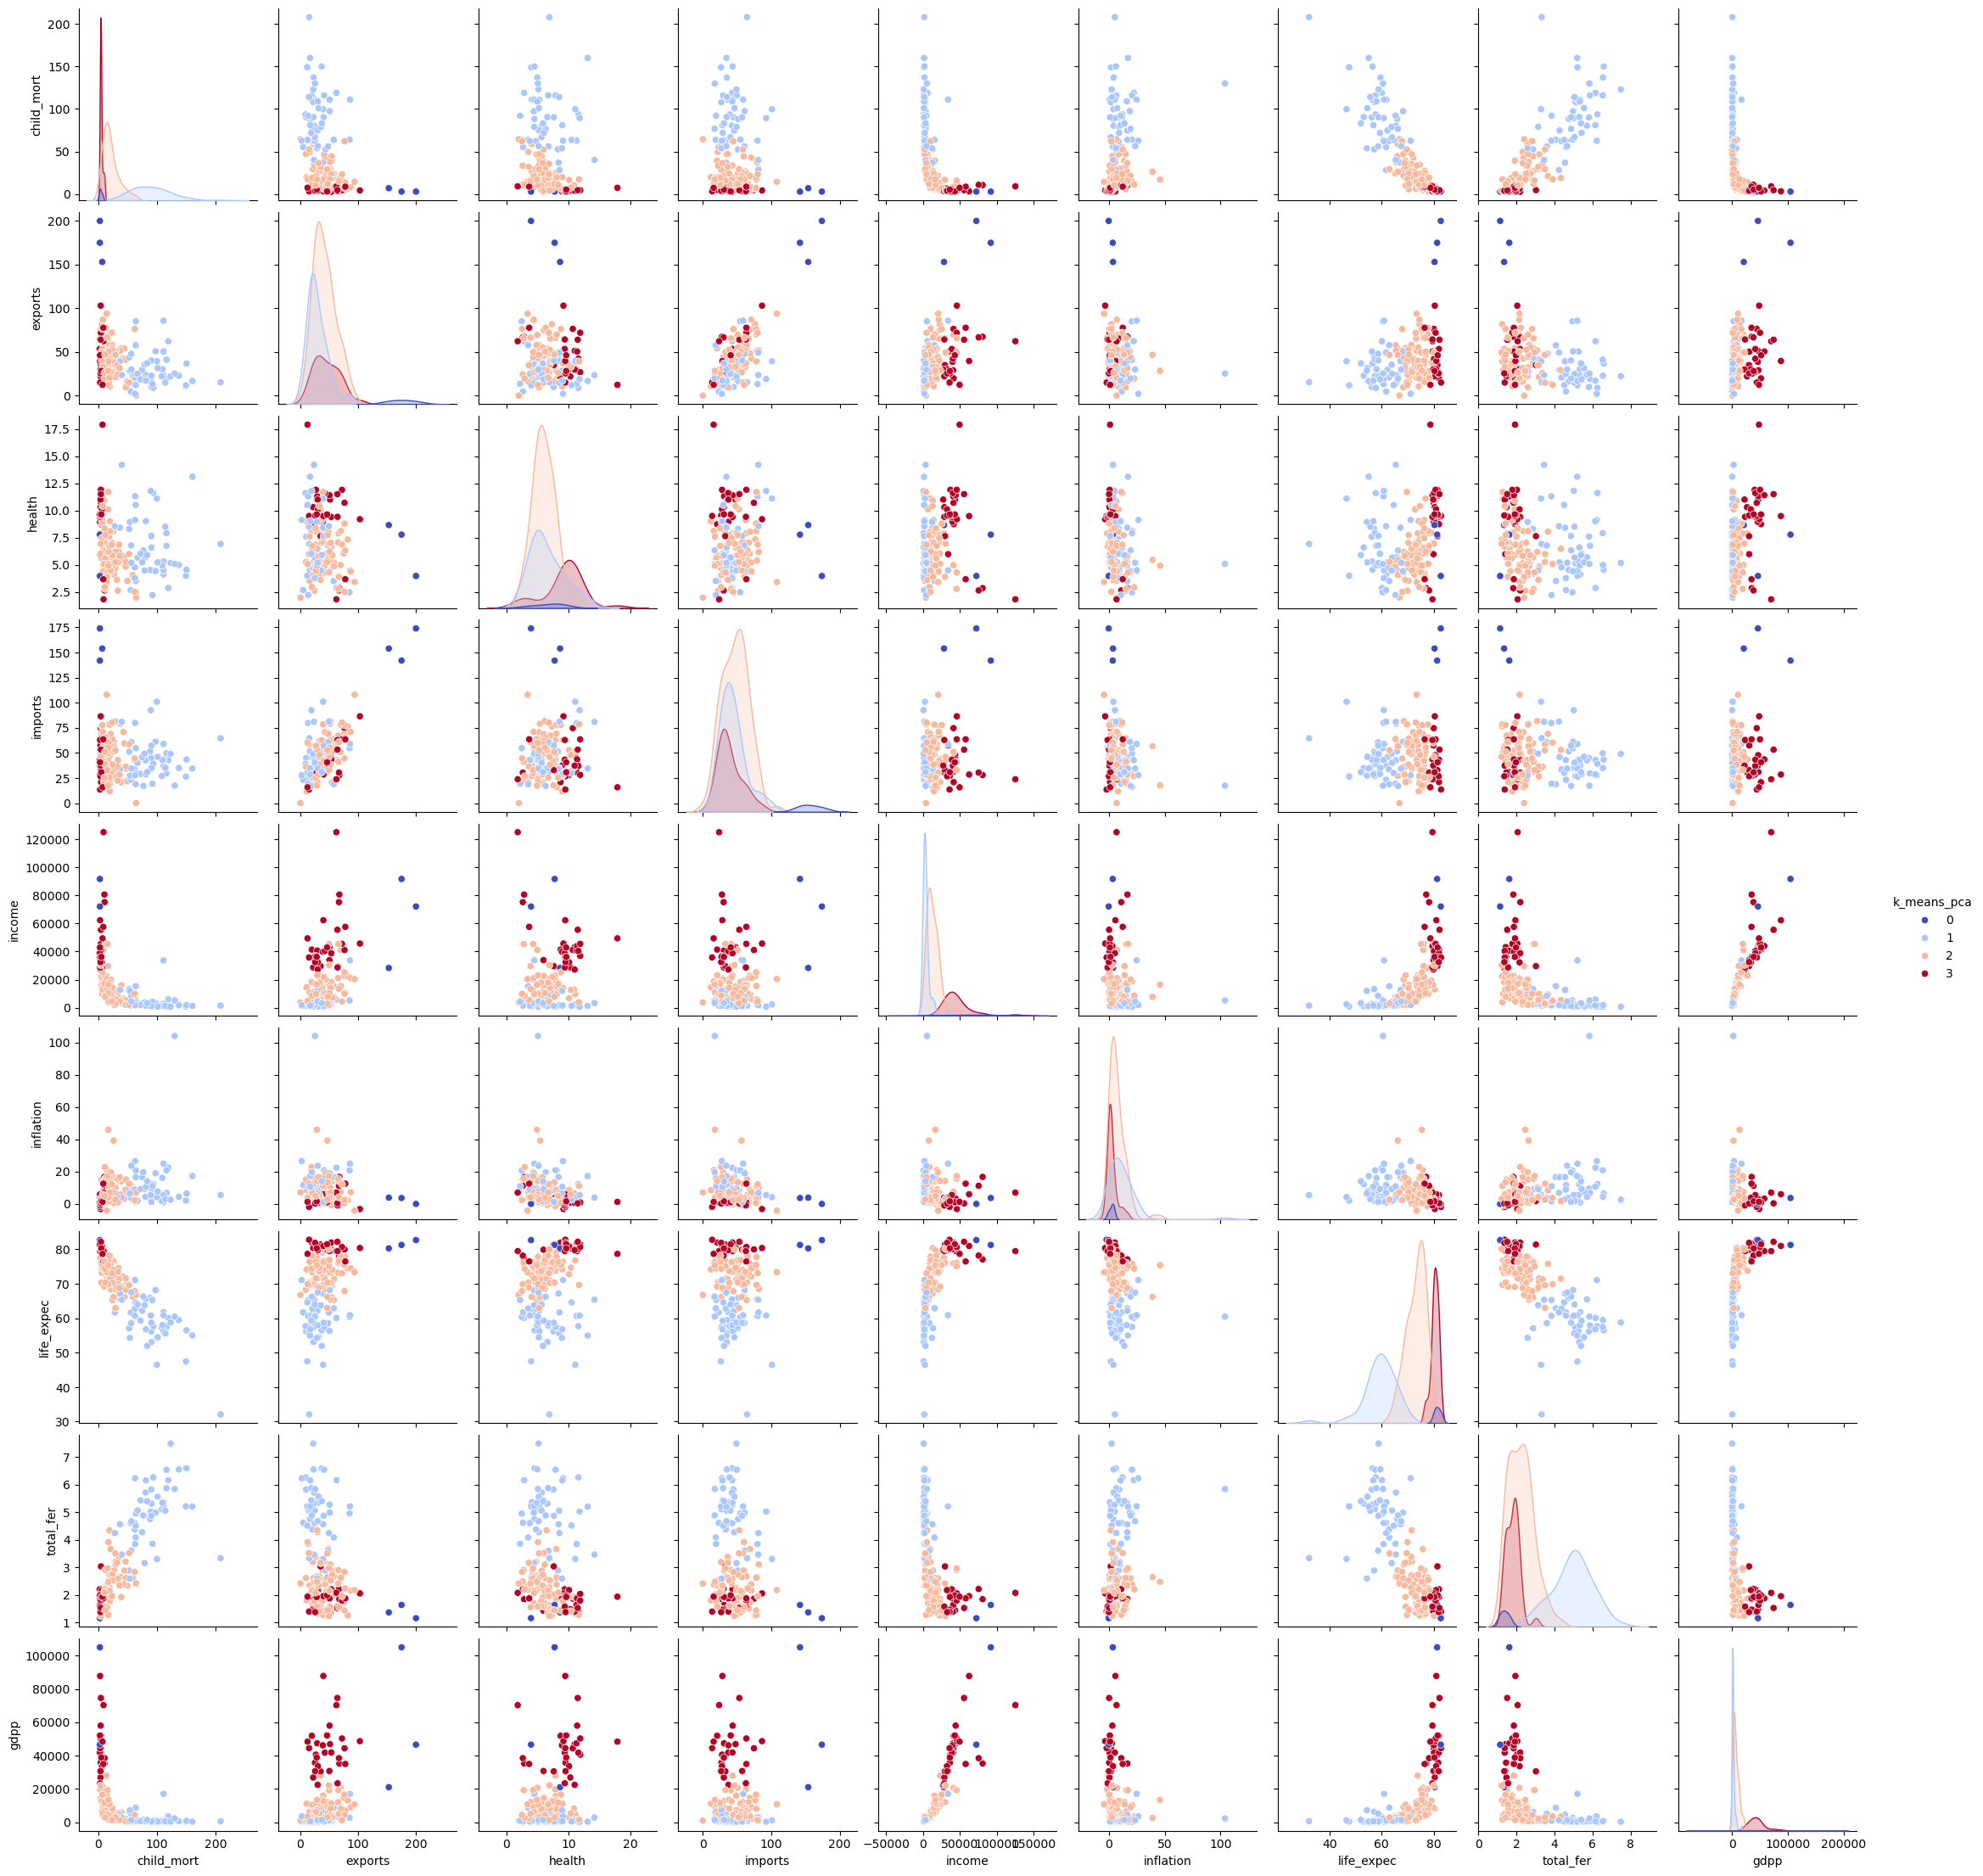

In [69]:
# sns.pairplot(...)
# Esta línea de código utiliza la función pairplot de la librería Seaborn para crear una
# matriz de gráficos. Esta matriz es una herramienta de visualización increíblemente útil.
# - En la diagonal, muestra la distribución de cada variable individual (generalmente como un histograma o un gráfico de densidad).
# - Fuera de la diagonal, muestra gráficos de dispersión (scatter plots) para cada par de variables.
# A continuación se detallan los argumentos utilizados:

sns.pairplot(
    # data = df_country[['child_mort', ..., 'k_means_pca']]
    # Este argumento especifica los datos que se van a utilizar.
    # - Se está seleccionando un subconjunto del DataFrame 'df_country'.
    # - Se incluyen varias columnas de características ('child_mort', 'exports', etc.) y, crucialmente,
    #   la columna 'k_means_pca', que contiene las etiquetas del clúster asignadas previamente.
    data = df_country[['child_mort', 'exports', 'health', 'imports', 'income',
                       'inflation', 'life_expec', 'total_fer', 'gdpp', 'k_means_pca']],
    
    # hue='k_means_pca'
    # Este es el argumento clave para visualizar los clústeres.
    # - Le indica a Seaborn que coloree los puntos de datos en cada gráfico de dispersión
    #   según la categoría a la que pertenecen en la columna 'k_means_pca'.
    # - Cada clúster (0, 1, 2, etc.) tendrá un color diferente, lo que permite ver
    #   visualizar cómo se separan (o se superponen) los grupos en diferentes dimensiones.
    hue='k_means_pca',
    
    # palette='coolwarm'
    # Este argumento define la paleta de colores que se usará para el argumento 'hue'.
    # - 'coolwarm' es una paleta de colores divergente (generalmente de azul a rojo).
    # - Asignará un color de esta paleta a cada etiqueta de clúster única.
    palette='coolwarm'
)


In [70]:
df_country

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_pca,k_means,hc_pca,hc,dbscan_pca,dbscan_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,1,1,0,0,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,3,0,0,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,3,1,0,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,1,1,0,-1,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2,3,0,0,0,0
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2,3,1,0,-1,-1
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2,3,0,0,0,0
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1,1,1,0,0,0


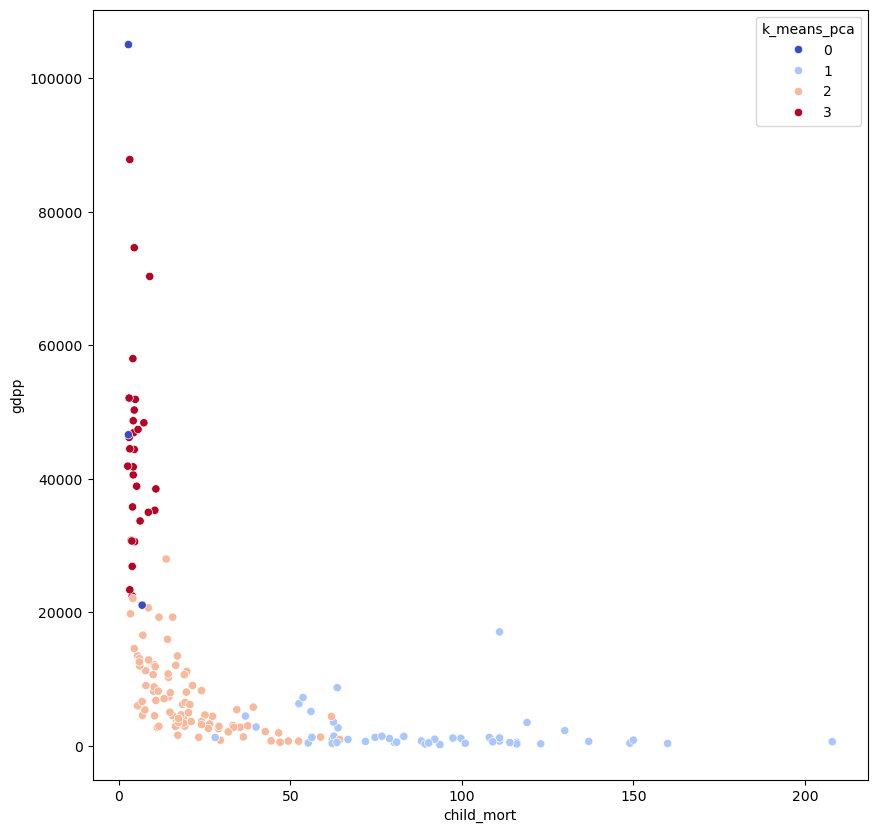

In [53]:
# fig = plt.figure(figsize=(10,10))
# Esta línea crea una nueva figura (un lienzo) de Matplotlib donde se dibujará el gráfico.
# - figsize=(10,10): Establece el tamaño de la figura a 10 pulgadas de ancho por 10 pulgadas de alto,
#   creando un área de dibujo cuadrada.
fig = plt.figure(figsize=(10,10))

# sns.scatterplot(data=df_country, x='child_mort', y='gdpp', hue='k_means_pca', palette='coolwarm')
# Esta es la función principal de Seaborn que crea el gráfico de dispersión.
# - sns.scatterplot: La función para dibujar los puntos.
# - data=df_country: Especifica que los datos provienen del DataFrame 'df_country'.
# - x='child_mort': Mapea la columna 'child_mort' (mortalidad infantil) al eje X.
# - y='gdpp': Mapea la columna 'gdpp' (PIB per cápita) al eje Y.
# - hue='k_means_pca': Este es el argumento más importante aquí. Le dice a Seaborn que
#   coloree cada punto según el valor de la columna 'k_means_pca' (la etiqueta del clúster).
#   Esto permite visualizar los diferentes grupos.
# - palette='coolwarm': Define la paleta de colores que se usará para los clústeres.
sns.scatterplot(data=df_country, x='child_mort', y='gdpp', hue='k_means_pca', palette='coolwarm')

# plt.show()
# Esta función de Matplotlib renderiza y muestra el gráfico que se ha configurado en las líneas anteriores.
# Sin esta llamada, el gráfico podría no aparecer en pantalla.
plt.show()


In [71]:
df_country[df_country['k_means_pca']==3]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_pca,k_means,hc_pca,hc,dbscan_pca,dbscan_cluster
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,3,0,0,1,0,0
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,3,0,0,1,0,0
15,Belgium,4.5,76.4,10.70,74.7,41100,1.880,80.0,1.86,44400,3,0,0,1,0,0
23,Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300,3,0,0,1,-1,-1
29,Canada,5.6,29.1,11.30,31.0,40700,2.870,81.3,1.63,47400,3,0,0,1,0,0
42,Cyprus,3.6,50.2,5.97,57.5,33900,2.010,79.9,1.42,30800,3,0,0,0,0,0
44,Denmark,4.1,50.5,11.40,43.6,44000,3.220,79.5,1.87,58000,3,0,0,1,0,0
53,Finland,3.0,38.7,8.95,37.4,39800,0.351,80.0,1.87,46200,3,0,0,1,0,0
54,France,4.2,26.8,11.90,28.1,36900,1.050,81.4,2.03,40600,3,0,0,1,0,0
58,Germany,4.2,42.3,11.60,37.1,40400,0.758,80.1,1.39,41800,3,0,0,1,0,0
